# Natural Language Processing
![](https://i.imgur.com/qkg2E2D.png)

## Assignment 002 - NER Tagger

> Notebook by:
> - NLP Course Staff
## Revision History

| Version | Date       | User        | Content / Changes                                                   |
|---------|------------|-------------|---------------------------------------------------------------------|
| 0.1.000 | 2026        | course staff | Updated submission protocol (direct from Colab) |

## Overview
In this assignment, you will build a complete training and testing pipeline for a neural sequential tagger for named entities using LSTM.

## Dataset
You will work with the ReCoNLL 2003 dataset, a corrected version of the [CoNLL 2003 dataset](https://www.clips.uantwerpen.be/conll2003/ner/):

**Click on the links below to download the data files.**
- [Train data](https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing)

- [Dev data](https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing)

- [Test data](https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing)

As you will see, the annotated texts are labeled according to the `IOB` annotation scheme (more on this below), for 3 entity types: Person, Organization, Location.

## Your Implementation

This notebook **is** the assignment template. To work on it, open it in Colab using the badge below and then **File → Save a copy in Drive** to create your own editable copy.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1KGkObwUn5QQm_v0nB0nAUlB4YrwThuzl#scrollTo=Z-fCqGh9ybgm)

Work through the cells in order — each section's instructions are written above the corresponding code cell.

Good Luck 🤗


<!-- ## NER schemes:  

> `IO`: is the simplest scheme that can be applied to this task. In this scheme, each token from the dataset is assigned one of two tags: an inside tag (`I`) and an outside tag (`O`). The `I` tag is for named entities, whereas the `O` tag is for normal words. This scheme has a limitation, as it cannot correctly encode consecutive entities of the same type.

> `IOB`: This scheme is also referred to in the literature as BIO and has been adopted by the Conference on Computational Natural Language Learning (CoNLL) [1]. It assigns a tag to each word in the text, determining whether it is the beginning (`B`) of a known named entity, inside (`I`) it, or outside (`O`) of any known named entities.

> `IOE`: This scheme works nearly identically to `IOB`, but it indicates the end of the entity (`E` tag) instead of its beginning.

> `IOBES`: An alternative to the IOB scheme is `IOBES`, which increases the amount of information related to the boundaries of named entities. In addition to tagging words at the beginning (`B`), inside (`I`), end (`E`), and outside (`O`) of a named entity. It also labels single-token entities with the tag `S`.

> `BI`: This scheme tags entities in a similar method to `IOB`. Additionally, it labels the beginning of non-entity words with the tag B-O and the rest as I-O.

> `IE`: This scheme works exactly like `IOE` with the distinction that it labels the end of non-entity words with the tag `E-O` and the rest as `I-O`.

> `BIES`: This scheme encodes the entities similar to `IOBES`. In addition, it also encodes the non-entity words using the same method. It uses `B-O` to tag the beginning of non-entity words, `I-O` to tag the inside of non-entity words, and `S-O` for single non-entity tokens that exist between two entities. -->


## NER Schemes

### IO
- **Description**: The simplest scheme for named entity recognition (NER).
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Limitation**: Cannot correctly encode consecutive entities of the same type.

### IOB (BIO)
- **Description**: Adopted by the Conference on Computational Natural Language Learning (CoNLL).
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Advantage**: Can encode the boundaries of consecutive entities.

### IOE
- **Description**: Similar to IOB, but indicates the end of an entity.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
- **Advantage**: Focuses on the end boundary of entities.

### IOBES
- **Description**: An extension of IOB with additional boundary information.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
- **Advantage**: Provides more detailed boundary information for named entities.

### BI
- **Description**: Tags entities similarly to IOB and labels the beginning of non-entity words.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Distinguishes the beginning of non-entity sequences.

### IE
- **Description**: Similar to IOE but for non-entity words.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `E-O`: End of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Highlights the end of non-entity sequences.

### BIES
- **Description**: Encodes both entities and non-entity words using the IOBES method.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
  - `S-O`: Single non-entity token.
- **Advantage**: Comprehensive encoding for both entities and non-entities.




# Set up

In [ ]:
# Clone the repo
! git clone https://github.com/NLP-Reichman/assignment-2-ner-erel-shelly-team.git
# Change the working directory to the cloned repo
%cd assignment-2-ner-erel-shelly-team

In [6]:
# Any additional needed libraries
! pip install -r requirements.txt

You should consider upgrading via the '/Users/erel.vanono/projects/msc-computer-science/nlp/assignment-2-ner-erel-shelly-team/.venv/bin/python3 -m pip install --upgrade pip' command.


In [4]:
# Standard Library Imports
import os
import copy
import random
import warnings
from collections import defaultdict
from typing import Optional

# ML
import numpy as np
import scipy as sp
import pandas as pd

# Visual
import matplotlib
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import display

# DL
import torch as th
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

# Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score , roc_auc_score, classification_report, confusion_matrix, precision_recall_fscore_support

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

In [5]:
SEED = 42
# Set the random seed for Python
random.seed(SEED)

# Set the random seed for numpy
np.random.seed(SEED)

# Set the random seed for pytorch
th.manual_seed(SEED)

# If using CUDA (for GPU operations)
th.cuda.manual_seed(SEED)

# Set up the device — this assignment expects a GPU runtime.
# In Colab: Runtime → Change runtime type → T4 GPU (or any available GPU).
# TO DO ----------------------------------------------------------------------
DEVICE = "cuda"
# TO DO ----------------------------------------------------------------------
assert th.cuda.is_available(), "No GPU detected. In Colab: Runtime → Change runtime type → GPU."
assert DEVICE == "cuda", "DEVICE must be set to 'cuda'."

DataType = list[tuple[list[str],list[str]]]

AssertionError: No GPU detected. In Colab: Runtime → Change runtime type → GPU.

# Part 1 - Dataset Preparation

## Step 1: Read Data
Write a function for reading the data from a single file (of the ones that are provided above).   
- The function recieves a filepath
- The funtion encodes every sentence individually using a pair of lists, one list contains the words and one list contains the tags.
- Each list pair will be added to a general list (data), which will be returned back from the function.

Example output:
```
[
  (['At','Trent','Bridge',':'],['O','B-LOC','I-LOC','O']),
  ([...],[...]),
  ...
]
```

In [ ]:
def read_data(filepath:str) -> DataType:
  """
  Read data from a single file.
  The function recieves a filepath
  The funtion encodes every sentence using a pair of lists, one list contains the words and one list contains the tags.
  :param filepath: path to the file
  :return: data as a list of tuples
  """
  data = []
  # TO DO ----------------------------------------------------------------------
  words = []
  tags = []

  with open(filepath, "r", encoding="utf-8") as file:
    for line in file:
      line = line.strip()

      if line == "":
        if words:
          data.append((words, tags))
          words = []
          tags = []
      else:
        word, tag = line.split()
        words.append(word)
        tags.append(tag)

  if words:
    data.append((words, tags))
  # TO DO ----------------------------------------------------------------------
  return data

In [ ]:
train = read_data("data/train.txt")
dev = read_data("data/dev.txt")
test = read_data("data/test.txt")

## Step 2: Create Vocab

The `Vocab` class will serve as a dictionary that maps words and tags into IDs. Ensure that you include special tokens to handle out-of-vocabulary words and padding.

### Your Task
1. **Define Special Tokens**: Define special tokens such as `PAD_TOKEN` and `UNK_TOKEN` and assign them unique IDs.
2. **Initialize Dictionaries**: Populate the word and tag dictionaries based on the training set.

*Note: You may change the `Vocab` class as needed.*

In [ ]:
# Initialize ids for special tokens.
# These must be defined *before* the Vocab class is instantiated,
# since Vocab.__init__ references them.
PAD_TOKEN = 0
UNK_TOKEN = 1

class Vocab:
  def __init__(self, train: DataType):
    """
    Initialize a Vocab instance.
    :param train: train data
    """
    self.word2id = {"__unk__": UNK_TOKEN, "__pad__": PAD_TOKEN}
    self.id2word = {UNK_TOKEN: "__unk__", PAD_TOKEN: "__pad__"}
    self.n_words = 2

    self.tag2id = {}
    self.id2tag = {}
    self.n_tags = 0

    # Initialize dictionaries based on the training set
    # TO DO ----------------------------------------------------------------------
    for words, tags in train:
      for word in words:
        if word not in self.word2id:
          self.word2id[word] = self.n_words
          self.id2word[self.n_words] = word
          self.n_words += 1

      for tag in tags:
        if tag not in self.tag2id:
          self.tag2id[tag] = self.n_tags
          self.id2tag[self.n_tags] = tag
          self.n_tags += 1

    # TO DO ----------------------------------------------------------------------

  def __len__(self):
    return self.n_words

  def index_tags(self, tags: list[str]) -> list[int]:
    """
    Convert tags to Ids.
    :param tags: list of tags
    :return: list of Ids
    """
    tag_indexes = [self.tag2id[t] for t in tags]
    return tag_indexes

  def index_words(self, words: list[str]) -> list[int]:
    """
    Convert words to Ids.
    :param words: list of words
    :return: list of Ids
    """
    word_indexes = [self.word2id[w] if w in self.word2id else self.word2id["__unk__"] for w in words]
    return word_indexes

In [ ]:
vocab = Vocab(train)

## Step 3: Prepare Data
Write a function `prepare_data` that takes one of the [train, dev, test] and the `Vocab` instance, for converting each pair of (words, tags) to a pair of indexes. Additionally, the function should pad the sequences to the maximum length sequence **of the given split**.

Note: Vocabulary is based only on the train set.

### Your Task
1. Convert each pair of (words, tags) to a pair of indexes using the Vocab instance.
2. Pad the sequences to the maximum length of the sequences in the given split.

In [ ]:
def prepare_data(data: DataType, vocab: Vocab):
  data_sequences = []
  # TO DO ----------------------------------------------------------------------
  max_len = max(len(words) for words, tags in data)

  for words, tags in data:
    word_ids = vocab.index_words(words)
    tag_ids = vocab.index_tags(tags)

    padding_size = max_len - len(word_ids)

    word_ids = word_ids + [PAD_TOKEN] * padding_size
    tag_ids = tag_ids + [vocab.tag2id["O"]] * padding_size

    data_sequences.append((word_ids, tag_ids))
  # TO DO ----------------------------------------------------------------------
  return data_sequences

In [ ]:
train_sequences = prepare_data(train, vocab)
dev_sequences = prepare_data(dev, vocab)
test_sequences = prepare_data(test, vocab)

### Your Task
Print the number of OOV in dev and test sets:

In [ ]:
def count_oov(sequences) -> int:
  """
  Count the number of OOV words.
  :param sequences: list of sequences
  :return: number of OOV words
  """
  oov = 0
  # TO DO ----------------------------------------------------------------------
  for word_ids, tag_ids in sequences:
      oov += word_ids.count(UNK_TOKEN)
  # TO DO ----------------------------------------------------------------------
  return oov

## Step 4: Dataloaders
Create dataloaders for each split in the dataset. They should return the samples as Tensors.

**Hint** - you can create a Dataset to support this part.

For the training set, use shuffling, and for the dev and test, not.

In [ ]:
class SequenceDataset(Dataset):
  def __init__(self, sequences):
    self.sequences = sequences

  def __len__(self):
    return len(self.sequences)

  def __getitem__(self, idx):
    word_ids, tag_ids = self.sequences[idx]
    return th.tensor(word_ids, dtype=th.long), th.tensor(tag_ids, dtype=th.long)

In [ ]:
def prepare_data_loader(sequences, batch_size: int, train: bool = True):
  """
  Create a dataloader from a list of sequences.
  :param sequences: list of sequences
  :param batch_size: batch size
  :param train: whether to shuffle the dataloader or not
  :return: dataloader
  """
  dataloader = None
  # TO DO ----------------------------------------------------------------------
  dataset = SequenceDataset(sequences)

  dataloader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=train
  )
  # TO DO ----------------------------------------------------------------------
  return dataloader

In [ ]:
BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

<br><br><br><br><br><br>

# Part 2 - NER Model Training

## Step 1: Implement Model

Write NERNet, a PyTorch Module for labeling words with NER tags.

> `input_size`: the size of the vocabulary  
`embedding_size`: the size of the embeddings  
`hidden_size`: the LSTM hidden size  
`output_size`: the number of tags we are predicting  
`n_layers`: the number of layers we want to use in LSTM  
`directions`: could 1 or 2, indicating unidirectional or bidirectional LSTM, respectively  

<br>  

The input for your forward function is a batch of sentence tensors with shape `(batch_size, seq_len)`.

*Note: the embeddings in this section are learned from scratch. That means you do **not** need pretrained embeddings here — you will use those in **Part 4**.*

*Note: You may change the NERNet class.*

In [ ]:
class NERNet(nn.Module):
  def __init__(self, input_size: int, embedding_size: int, hidden_size: int, output_size: int, n_layers: int, directions: int):
    """
    Initialize a NERNet instance.
    :param input_size: the size of the vocabulary
    :param embedding_size: the size of the embeddings
    :param hidden_size: the LSTM hidden size
    :param output_size: the number of tags we are predicting
    :param n_layers: the number of layers we want to use in LSTM
    :param directions: could be 1 or 2, indicating unidirectional or bidirectional LSTM, respectively
    """
    super(NERNet, self).__init__()
    # TO DO ----------------------------------------------------------------------
    self.embedding = nn.Embedding(input_size, embedding_size, padding_idx=PAD_TOKEN)

    self.lstm = nn.LSTM(
        input_size=embedding_size,
        hidden_size=hidden_size,
        num_layers=n_layers,
        batch_first=True,
        bidirectional=(directions == 2)
    )

    self.fc = nn.Linear(hidden_size * directions, output_size)
    # TO DO ----------------------------------------------------------------------

  def forward(self, input_sentence):
    # TO DO ----------------------------------------------------------------------
    # input_sentence: (batch_size, seq_len)
    embedded = self.embedding(input_sentence)

    lstm_out, _ = self.lstm(embedded)

    output = self.fc(lstm_out)
    # TO DO ----------------------------------------------------------------------
    return output

In [ ]:
model = NERNet(vocab.n_words, embedding_size=300, hidden_size=800, output_size=vocab.n_tags, n_layers=2, directions=1)
model.to(DEVICE)

NERNet(
  (embedding): Embedding(7163, 300, padding_idx=0)
  (lstm): LSTM(300, 800, num_layers=2, batch_first=True)
  (fc): Linear(in_features=800, out_features=7, bias=True)
)

## Step 2: Training Loop

Write a training loop, which takes a model (instance of NERNet), number of epochs to train on, and the train&dev datasets.  

The function will return the `loss` and `accuracy` durring training.  
(If you're using a different/additional metrics, return them too)

The loss is always CrossEntropyLoss and the optimizer is always Adam.
Make sure to use `tqdm` while iterating on `n_epochs`.


In [ ]:
def train_loop(model: NERNet, n_epochs: int, dataloader_train, dataloader_dev):
  """
  Train a model.
  :param model: model instance
  :param n_epochs: number of epochs to train on
  :param dataloader_train: train dataloader
  :param dataloader_dev: dev dataloader
  :return: loss and accuracy during training
  """

  optimizer = Adam(model.parameters(), lr=0.0001)

  metrics = {'loss': {'train': [], 'dev': []}, 'accuracy': {'train': [], 'dev': []}}

  model.to(DEVICE)

  ## TO DO ----------------------------------------------------------------------
  loss_fn = nn.CrossEntropyLoss()

  for epoch in tqdm(range(n_epochs)):

    # Train
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for words_batch, tags_batch in dataloader_train:
      words_batch = words_batch.to(DEVICE)
      tags_batch = tags_batch.to(DEVICE)

      optimizer.zero_grad()

      outputs = model(words_batch)  # (batch_size, seq_len, n_tags)

      mask = words_batch != PAD_TOKEN

      outputs_masked = outputs[mask]
      tags_masked = tags_batch[mask]

      loss = loss_fn(outputs_masked, tags_masked)

      loss.backward()
      optimizer.step()

      train_loss += loss.item()

      preds = outputs_masked.argmax(dim=1)
      train_correct += (preds == tags_masked).sum().item()
      train_total += tags_masked.numel()

    train_loss = train_loss / len(dataloader_train)
    train_acc = train_correct / train_total

    # Dev
    model.eval()
    dev_loss = 0
    dev_correct = 0
    dev_total = 0

    with th.no_grad():
      for words_batch, tags_batch in dataloader_dev:
        words_batch = words_batch.to(DEVICE)
        tags_batch = tags_batch.to(DEVICE)

        outputs = model(words_batch)

        mask = words_batch != PAD_TOKEN

        outputs_masked = outputs[mask]
        tags_masked = tags_batch[mask]

        loss = loss_fn(outputs_masked, tags_masked)

        dev_loss += loss.item()

        preds = outputs_masked.argmax(dim=1)
        dev_correct += (preds == tags_masked).sum().item()
        dev_total += tags_masked.numel()

    dev_loss = dev_loss / len(dataloader_dev)
    dev_acc = dev_correct / dev_total

    metrics['loss']['train'].append(train_loss)
    metrics['loss']['dev'].append(dev_loss)
    metrics['accuracy']['train'].append(train_acc)
    metrics['accuracy']['dev'].append(dev_acc)
  # TO DO ----------------------------------------------------------------------

  return metrics

In [ ]:
metrics = train_loop(model, n_epochs=5, dataloader_train=dl_train, dataloader_dev=dl_dev)
metrics

100%|██████████| 5/5 [00:22<00:00,  4.59s/it]


{'loss': {'train': [1.0548551711169156,
   0.7523869162256067,
   0.6178234747864984,
   0.5269122578881004,
   0.44520550586960533],
  'dev': [0.8468424901366234,
   0.6927929557859898,
   0.5994586050510406,
   0.5477360617369413,
   0.5169077925384045]},
 'accuracy': {'train': [0.7872714486638537,
   0.7924402250351618,
   0.814803094233474,
   0.8305555555555556,
   0.8549226441631504],
  'dev': [0.7849353284301294,
   0.8034491503931017,
   0.817651534364697,
   0.8308394623383211,
   0.8460563023078874]}}

<br><br><br><br><br><br>

# Part 3 - Evaluation


## Step 1: Evaluation Function

Write an evaluation loop for a trained model using the dev and test datasets. This function will print the `Recall`, `Precision`, and `F1` scores and plot a `Confusion Matrix`.

Perform this evaluation twice:
1. For all labels (7 labels in total).
2. For all labels except "O" (6 labels in total).

## Metrics and Display

### Metrics
- **Recall**: The fraction of true positives that were correctly predicted — TP / (TP + FN). Also known as the True Positive Rate (TPR).
- **Precision**: The fraction of predicted positives that are actually correct — TP / (TP + FP).
- **F1 Score**: The harmonic mean of Precision and Recall.

*Note*: For all these metrics, use **weighted** averaging:
Calculate metrics for each label, and find their average weighted by support. Refer to the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support) for more details.

### Display
1. Print the `Recall`, `Precision`, and `F1` scores in a tabulated format.
2. Display a `Confusion Matrix` plot:
   - Rows represent the predicted labels.
   - Columns represent the true labels.
   - Include a title for the plot, axis names, and the names of the tags on the X-axis.

In [ ]:
def evaluate(model: NERNet, title: str, dataloader: DataLoader, vocab: Vocab):
  """
  Evaluate a trained model on the given dataset.
  :param model: model instance
  :param title: title for the plot
  :param dataloader: dataloader
  :param vocab: Vocab instance
  :return: Dictionary of evaluation results
  """
  results = {}

  # TO DO ----------------------------------------------------------------------
  model.eval()
  model.to(DEVICE)

  y_true = []
  y_pred = []

  with th.no_grad():
    for words_batch, tags_batch in dataloader:
      words_batch = words_batch.to(DEVICE)
      tags_batch = tags_batch.to(DEVICE)

      outputs = model(words_batch)              # (batch_size, seq_len, n_tags)
      preds = outputs.argmax(dim=2)             # (batch_size, seq_len)

      mask = words_batch != PAD_TOKEN           # ignore padding

      y_true.extend(tags_batch[mask].cpu().numpy())
      y_pred.extend(preds[mask].cpu().numpy())

  label_ids = sorted(vocab.id2tag.keys())
  label_names = [vocab.id2tag[i] for i in label_ids]

  def compute_and_display(curr_true, curr_pred, curr_label_ids, curr_label_names, subtitle):
    precision, recall, f1, _ = precision_recall_fscore_support(
        curr_true,
        curr_pred,
        labels=curr_label_ids,
        average="weighted",
        zero_division=0
    )

    table = [
        ["Precision", precision],
        ["Recall", recall],
        ["F1", f1]
    ]

    print(f"\n{title} - {subtitle}")
    print(tabulate(table, headers=["Metric", "Score"], floatfmt=".4f"))

    cm = confusion_matrix(
        curr_true,
        curr_pred,
        labels=curr_label_ids
    )

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=curr_label_names,
        yticklabels=curr_label_names
    )
    plt.title(f"{title} - {subtitle}")
    plt.xlabel("True labels")
    plt.ylabel("Predicted labels")
    plt.show()

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm
    }

  results["all_labels"] = compute_and_display(
      y_true,
      y_pred,
      label_ids,
      label_names,
      "All labels"
  )

  o_id = vocab.tag2id["O"]
  no_o_label_ids = [i for i in label_ids if i != o_id]
  no_o_label_names = [vocab.id2tag[i] for i in no_o_label_ids]

  y_true_no_o = []
  y_pred_no_o = []

  for true_tag, pred_tag in zip(y_true, y_pred):
    if true_tag != o_id:
      y_true_no_o.append(true_tag)
      y_pred_no_o.append(pred_tag)

  results["without_o"] = compute_and_display(
      y_true_no_o,
      y_pred_no_o,
      no_o_label_ids,
      no_o_label_names,
      'Without "O"'
  )
  # TO DO ----------------------------------------------------------------------

  return results

## Step 2: Train & Evaluate on Dev Set

Train and evaluate (on the dev set) a few models, all with `embedding_size=300` and `N_EPOCHS=5` (for fairness and computational reasons), and with the following hyper parameters (you may use that as captions for the models as well):

- Model 1: (hidden_size: 500, n_layers: 1, directions: 1)
- Model 2: (hidden_size: 500, n_layers: 2, directions: 1)
- Model 3: (hidden_size: 500, n_layers: 3, directions: 1)
- Model 4: (hidden_size: 500, n_layers: 1, directions: 2)
- Model 5: (hidden_size: 500, n_layers: 2, directions: 2)
- Model 6: (hidden_size: 500, n_layers: 3, directions: 2)
- Model 7: (hidden_size: 800, n_layers: 1, directions: 2)
- Model 8: (hidden_size: 800, n_layers: 2, directions: 2)
- Model 9: (hidden_size: 800, n_layers: 3, directions: 2)




In [ ]:
N_EPOCHS = 5
EMB_DIM = 300

Here is an example (random numbers) of the display of the results):

In [ ]:
# Example:
results_acc = np.random.rand(9, 10)
columns = ['N_MODEL','HIDDEN_SIZE','N_LAYERS','DIRECTIONS','RECALL','PRECISION','F1','RECALL_WO_O','PRECISION_WO_O','F1_WO_O']
df = pd.DataFrame(results_acc, columns=columns)
df.N_MODEL = [f'model_{n}' for n in range(1,10)]
print(tabulate(df, headers='keys', tablefmt='psql',floatfmt=".4f"))

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |        0.9507 |     0.7320 |       0.5987 |   0.1560 |      0.1560 | 0.0581 |        0.8662 |           0.6011 |    0.7081 |
|  1 | model_2   |        0.9699 |     0.8324 |       0.2123 |   0.1818 |      0.1834 | 0.3042 |        0.5248 |           0.4319 |    0.2912 |
|  2 | model_3   |        0.1395 |     0.2921 |       0.3664 |   0.4561 |      0.7852 | 0.1997 |        0.5142 |           0.5924 |    0.0465 |
|  3 | model_4   |        0.1705 |     0.0651 |       0.9489 |   0.9656 |      0.8084 | 0.3046 |        0.0977 |           0.6842 |    0

Training Model1...


100%|██████████| 5/5 [00:07<00:00,  1.48s/it]



Model1 - All labels
Metric       Score
---------  -------
Precision   0.7728
Recall      0.8192
F1          0.7692


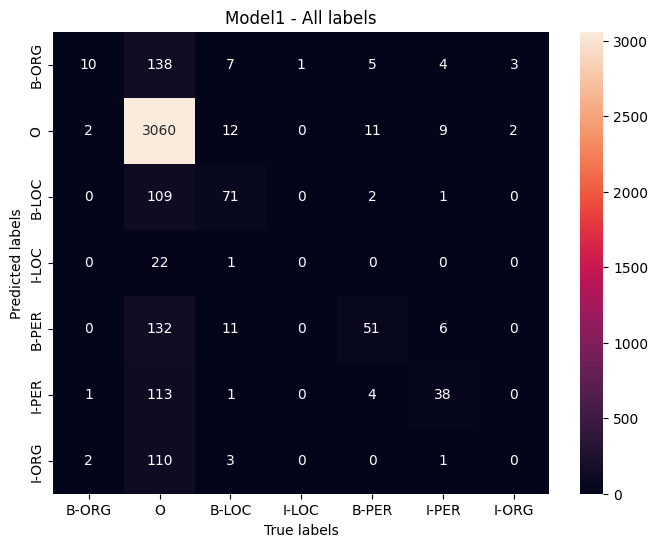


Model1 - Without "O"
Metric       Score
---------  -------
Precision   0.6509
Recall      0.2007
F1          0.2927


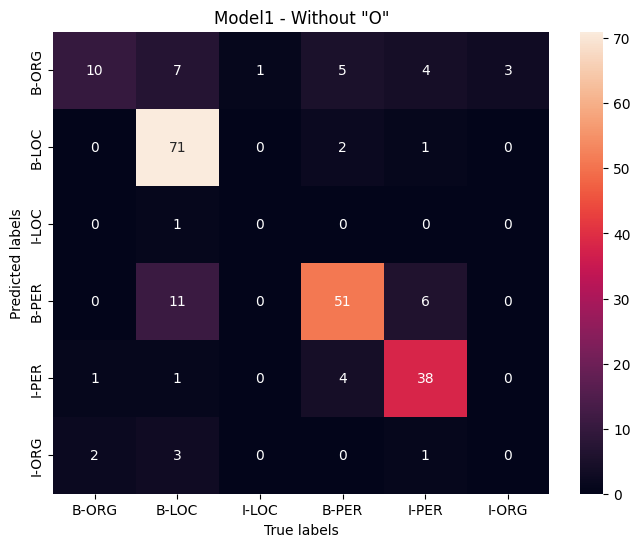

Training Model2...


100%|██████████| 5/5 [00:09<00:00,  1.99s/it]



Model2 - All labels
Metric       Score
---------  -------
Precision   0.7780
Recall      0.8062
F1          0.7780


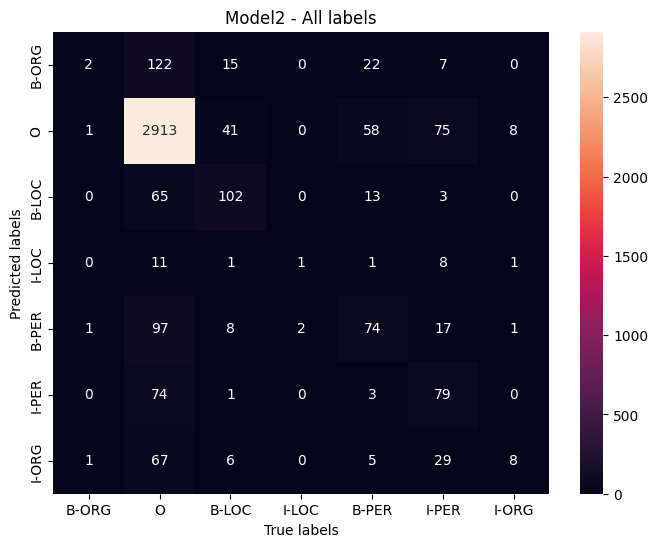


Model2 - Without "O"
Metric       Score
---------  -------
Precision   0.6340
Recall      0.3140
F1          0.3711


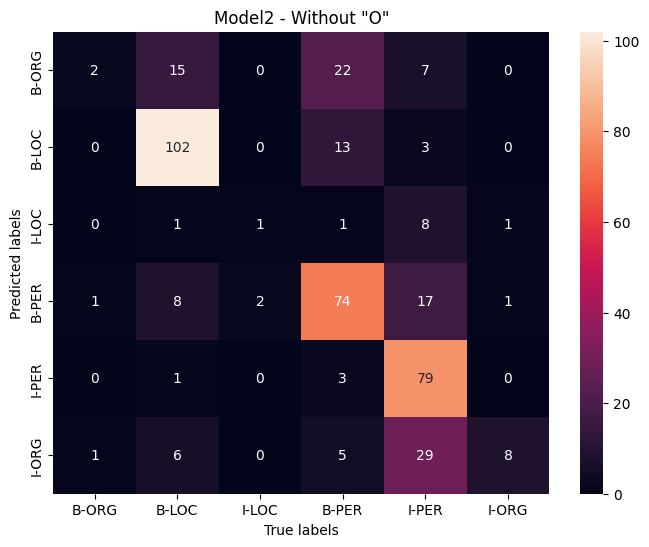

Training Model3...


100%|██████████| 5/5 [00:14<00:00,  2.85s/it]



Model3 - All labels
Metric       Score
---------  -------
Precision   0.7914
Recall      0.8263
F1          0.7921


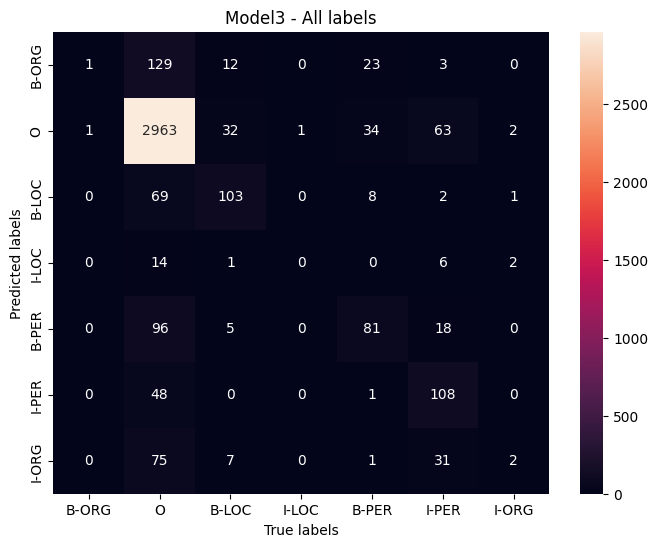


Model3 - Without "O"
Metric       Score
---------  -------
Precision   0.7139
Recall      0.3483
F1          0.3950


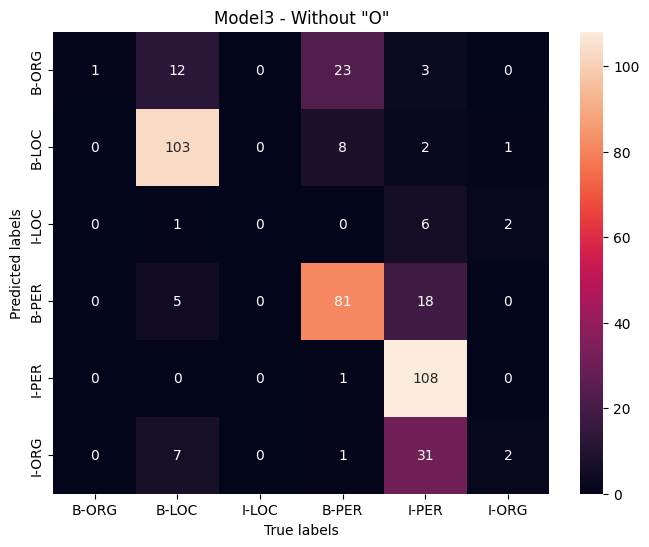

Training Model4...


100%|██████████| 5/5 [00:08<00:00,  1.79s/it]



Model4 - All labels
Metric       Score
---------  -------
Precision   0.8370
Recall      0.8527
F1          0.8270


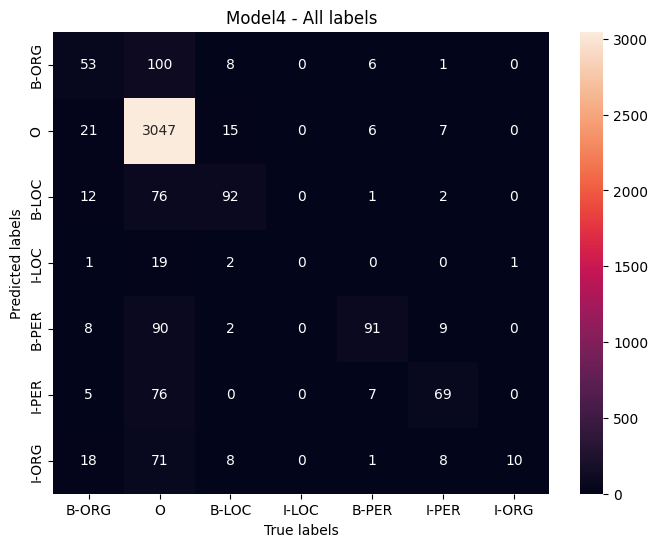


Model4 - Without "O"
Metric       Score
---------  -------
Precision   0.7568
Recall      0.3719
F1          0.4801


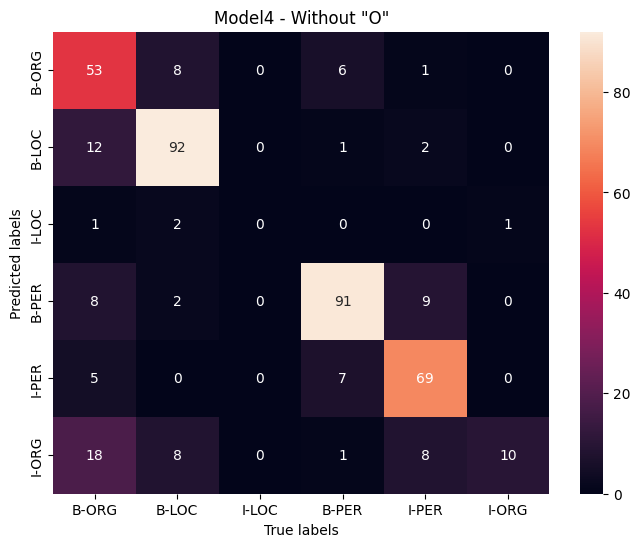

Training Model5...


100%|██████████| 5/5 [00:19<00:00,  3.93s/it]



Model5 - All labels
Metric       Score
---------  -------
Precision   0.8752
Recall      0.8689
F1          0.8703


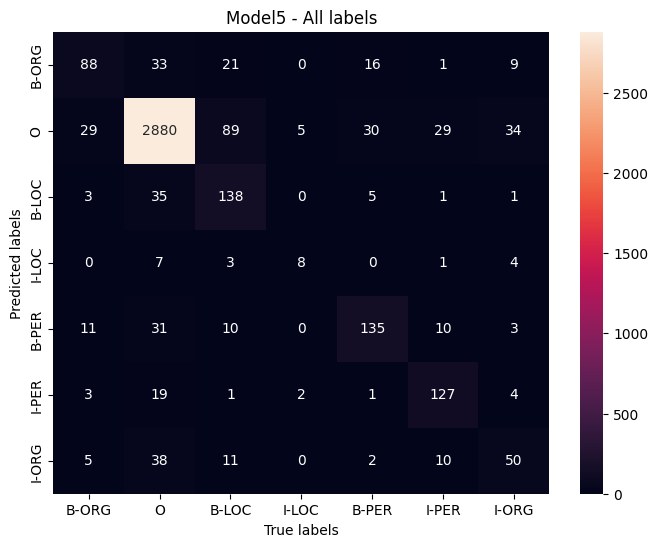


Model5 - Without "O"
Metric       Score
---------  -------
Precision   0.7963
Recall      0.6446
F1          0.7054


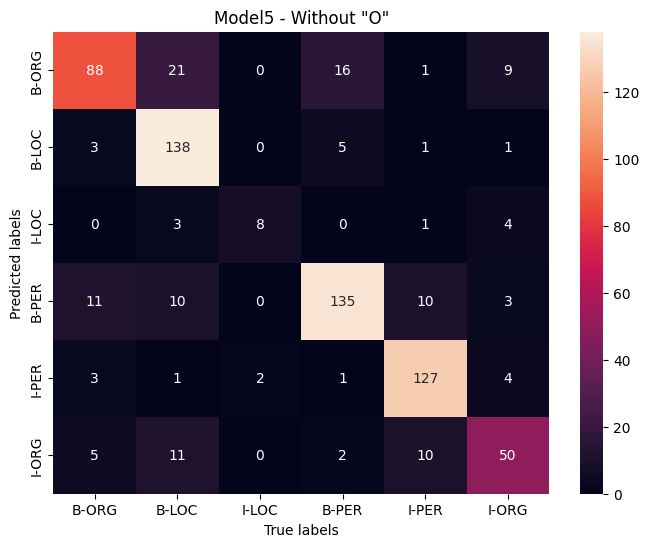

Training Model6...


100%|██████████| 5/5 [00:31<00:00,  6.23s/it]



Model6 - All labels
Metric       Score
---------  -------
Precision   0.8634
Recall      0.8722
F1          0.8563


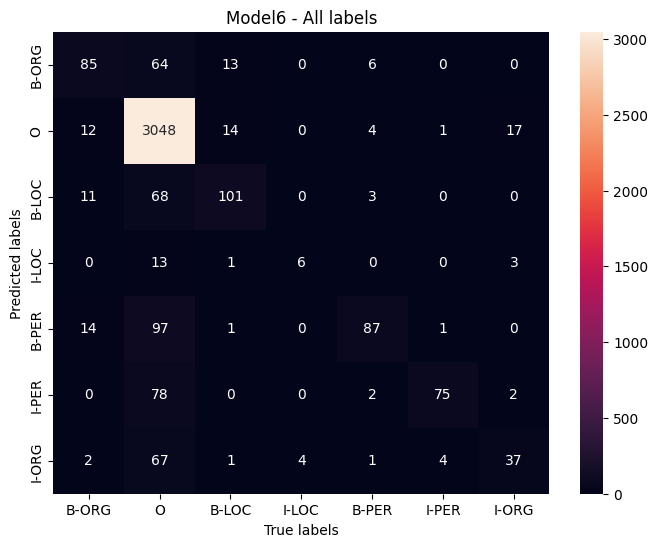


Model6 - Without "O"
Metric       Score
---------  -------
Precision   0.8553
Recall      0.4616
F1          0.5946


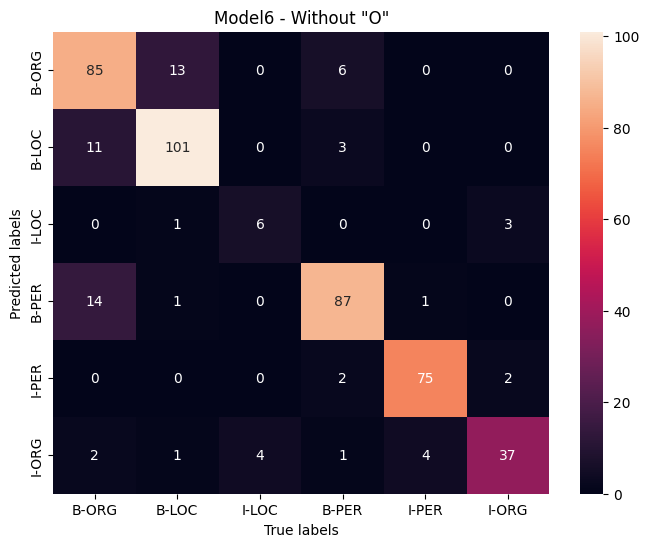

Training Model7...


100%|██████████| 5/5 [00:20<00:00,  4.15s/it]



Model7 - All labels
Metric       Score
---------  -------
Precision   0.8463
Recall      0.8595
F1          0.8367


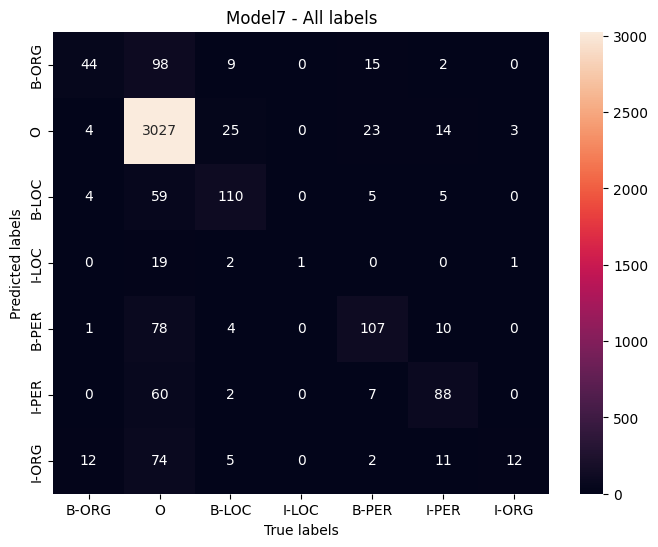


Model7 - Without "O"
Metric       Score
---------  -------
Precision   0.8031
Recall      0.4274
F1          0.5248


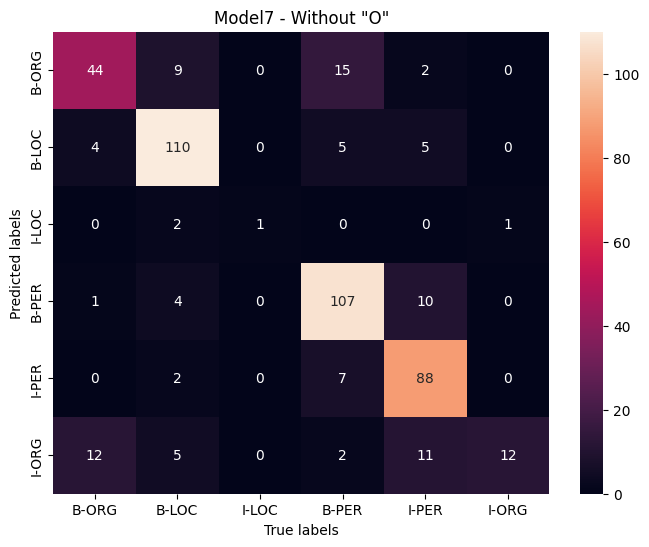

Training Model8...


100%|██████████| 5/5 [00:52<00:00, 10.45s/it]



Model8 - All labels
Metric       Score
---------  -------
Precision   0.8791
Recall      0.8816
F1          0.8788


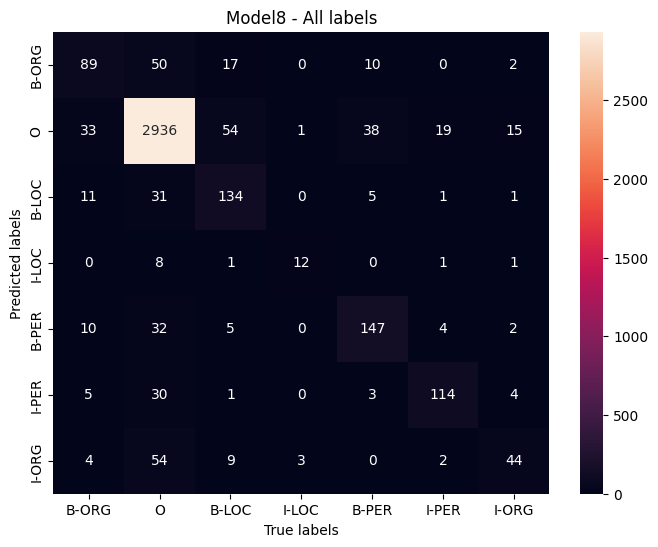


Model8 - Without "O"
Metric       Score
---------  -------
Precision   0.8386
Recall      0.6375
F1          0.7182


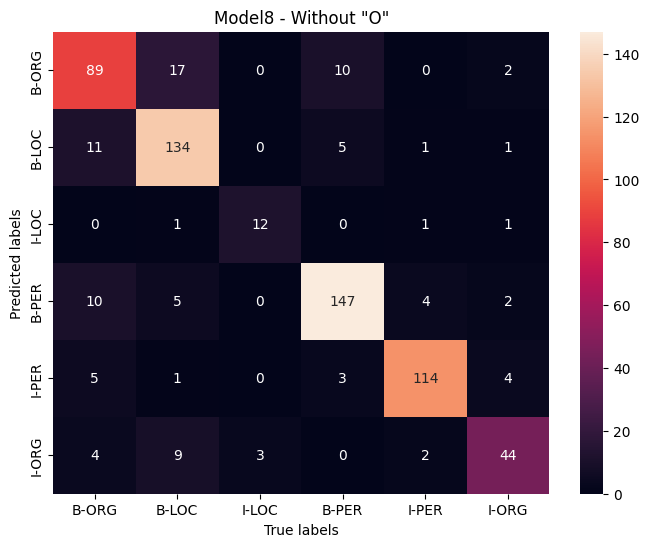

Training Model9...


100%|██████████| 5/5 [01:23<00:00, 16.67s/it]



Model9 - All labels
Metric       Score
---------  -------
Precision   0.8902
Recall      0.8950
F1          0.8818


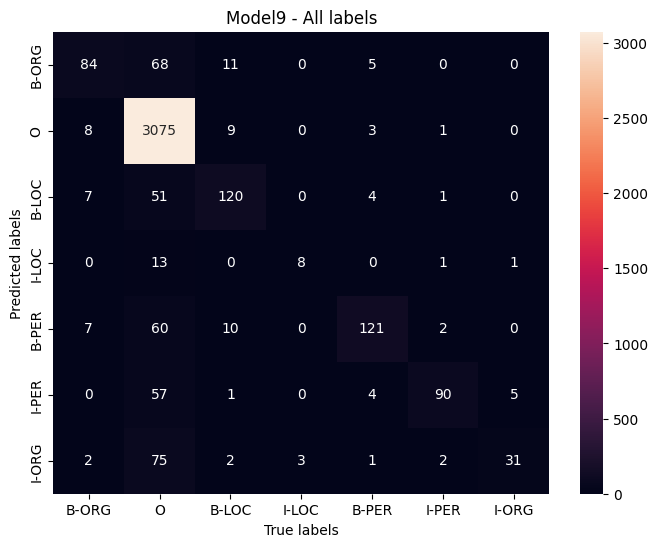


Model9 - Without "O"
Metric       Score
---------  -------
Precision   0.8666
Recall      0.5360
F1          0.6536


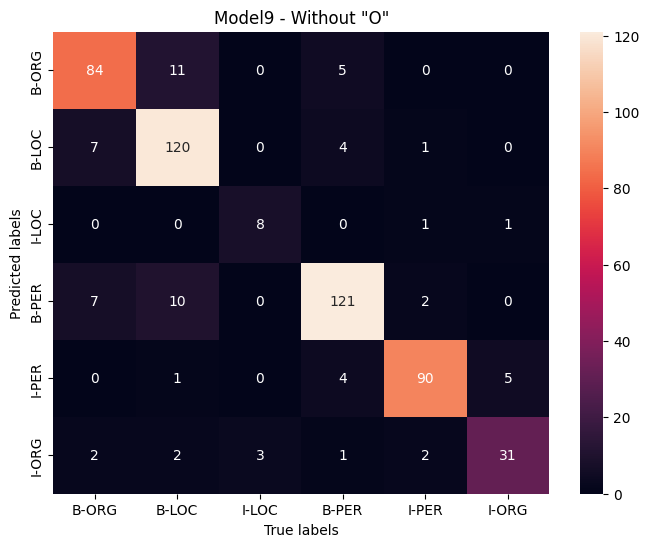

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | Model1    |           500 |          1 |            1 |   0.8192 |      0.7728 | 0.7692 |        0.2007 |           0.6509 |    0.2927 |
|  1 | Model2    |           500 |          2 |            1 |   0.8062 |      0.7780 | 0.7780 |        0.3140 |           0.6340 |    0.3711 |
|  2 | Model3    |           500 |          3 |            1 |   0.8263 |      0.7914 | 0.7921 |        0.3483 |           0.7139 |    0.3950 |
|  3 | Model4    |           500 |          1 |            2 |   0.8527 |      0.8370 | 0.8270 |        0.3719 |           0.7568 |    0

In [ ]:
# Define models with their hyperparameters
models = {
  'Model1': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 1},
  'Model2': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 1},
  'Model3': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 1},
  'Model4': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 2},
  'Model5': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 2},
  'Model6': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 2},
  'Model7': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 1, 'directions': 2},
  'Model8': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 2, 'directions': 2},
  'Model9': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 3, 'directions': 2},
}

# TO DO ----------------------------------------------------------------------
results_rows = []

for model_name, params in models.items():
  print(f"Training {model_name}...")

  model = NERNet(
      input_size=len(vocab),
      embedding_size=params["embedding_size"],
      hidden_size=params["hidden_size"],
      output_size=vocab.n_tags,
      n_layers=params["n_layers"],
      directions=params["directions"]
  )

  train_loop(
      model=model,
      n_epochs=N_EPOCHS,
      dataloader_train=dl_train,
      dataloader_dev=dl_dev
  )

  eval_results = evaluate(
      model=model,
      title=model_name,
      dataloader=dl_dev,
      vocab=vocab
  )

  results_rows.append({
      "N_MODEL": model_name,
      "HIDDEN_SIZE": params["hidden_size"],
      "N_LAYERS": params["n_layers"],
      "DIRECTIONS": params["directions"],
      "RECALL": eval_results["all_labels"]["recall"],
      "PRECISION": eval_results["all_labels"]["precision"],
      "F1": eval_results["all_labels"]["f1"],
      "RECALL_WO_O": eval_results["without_o"]["recall"],
      "PRECISION_WO_O": eval_results["without_o"]["precision"],
      "F1_WO_O": eval_results["without_o"]["f1"],
  })

results_dev = pd.DataFrame(results_rows)
# TO DO ----------------------------------------------------------------------

# Print results in tabulated format
print(tabulate(results_dev, headers='keys', tablefmt='psql', floatfmt=".4f"))

## Step 3: Evaluate on Test Set
Evaluate your models on the test set and save the results as a CSV.

Training and evaluating Model1 on test...


100%|██████████| 5/5 [00:05<00:00,  1.09s/it]



Model1 - Test - All labels
Metric       Score
---------  -------
Precision   0.7928
Recall      0.8236
F1          0.7703


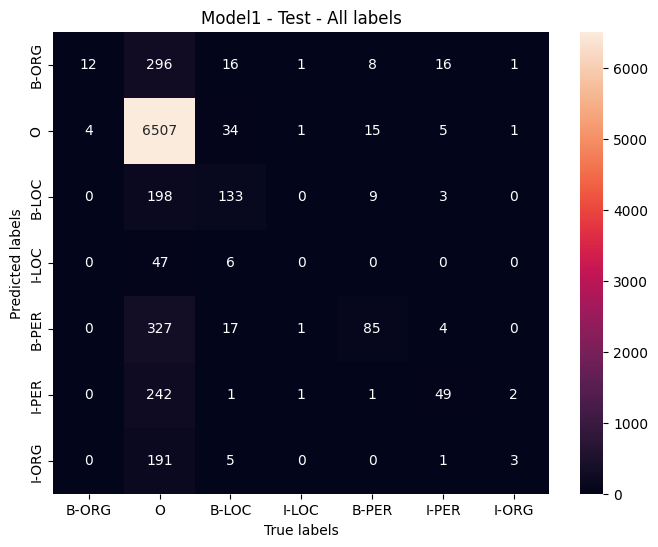


Model1 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.7537
Recall      0.1683
F1          0.2507


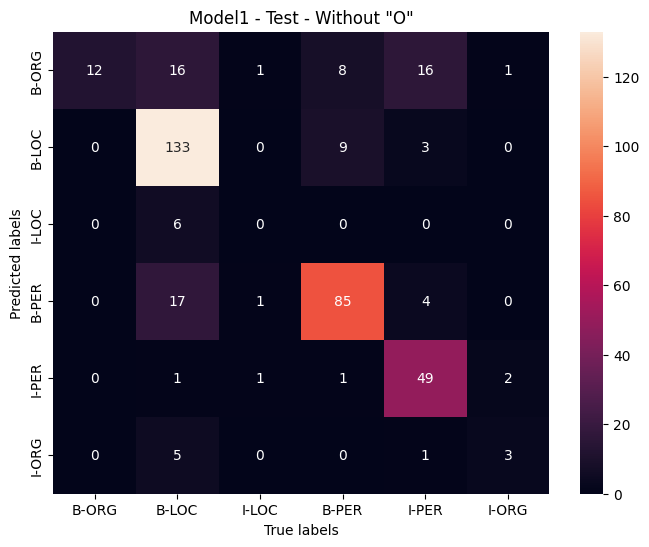

Training and evaluating Model2 on test...


100%|██████████| 5/5 [00:09<00:00,  1.95s/it]



Model2 - Test - All labels
Metric       Score
---------  -------
Precision   0.7905
Recall      0.8283
F1          0.7798


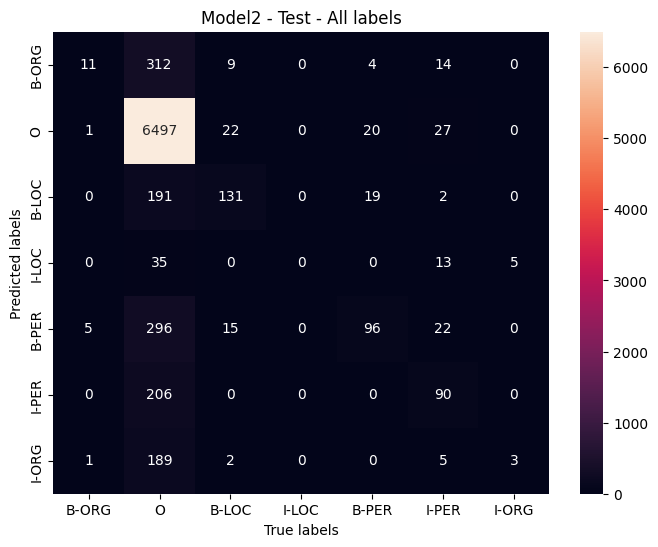


Model2 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.6684
Recall      0.1975
F1          0.2850


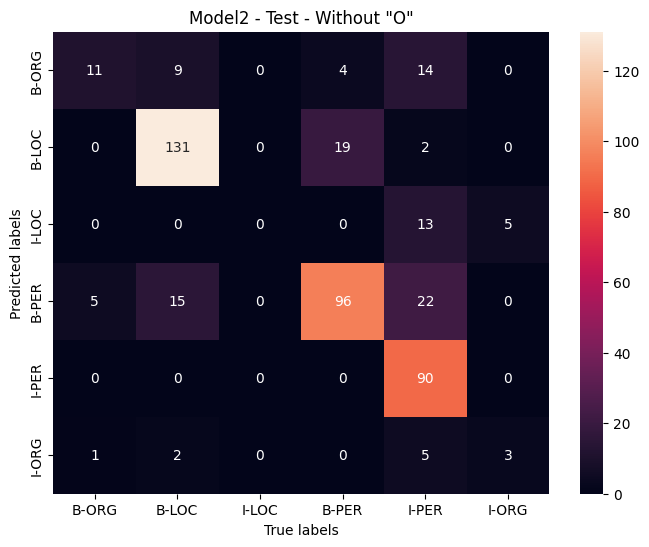

Training and evaluating Model3 on test...


100%|██████████| 5/5 [00:14<00:00,  2.83s/it]



Model3 - Test - All labels
Metric       Score
---------  -------
Precision   0.7890
Recall      0.8304
F1          0.7940


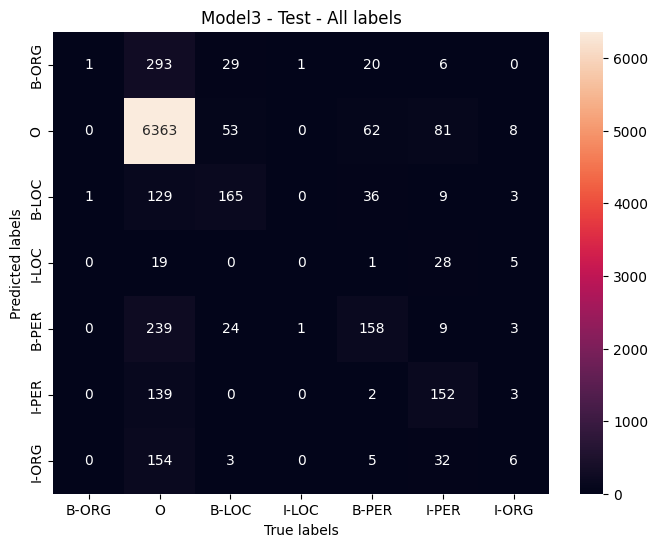


Model3 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.5911
Recall      0.2876
F1          0.3531


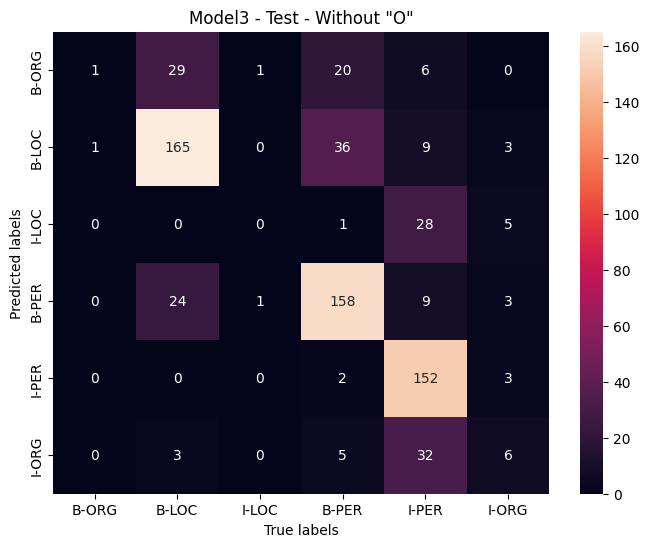

Training and evaluating Model4 on test...


100%|██████████| 5/5 [00:09<00:00,  1.80s/it]



Model4 - Test - All labels
Metric       Score
---------  -------
Precision   0.8513
Recall      0.8548
F1          0.8204


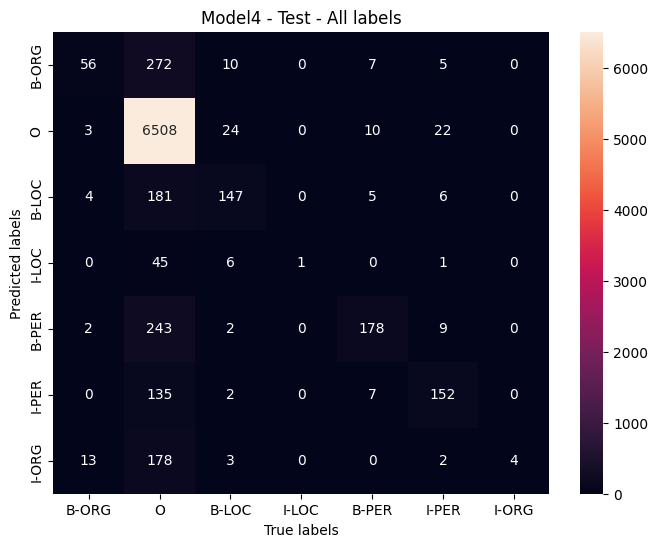


Model4 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.8712
Recall      0.3210
F1          0.4383


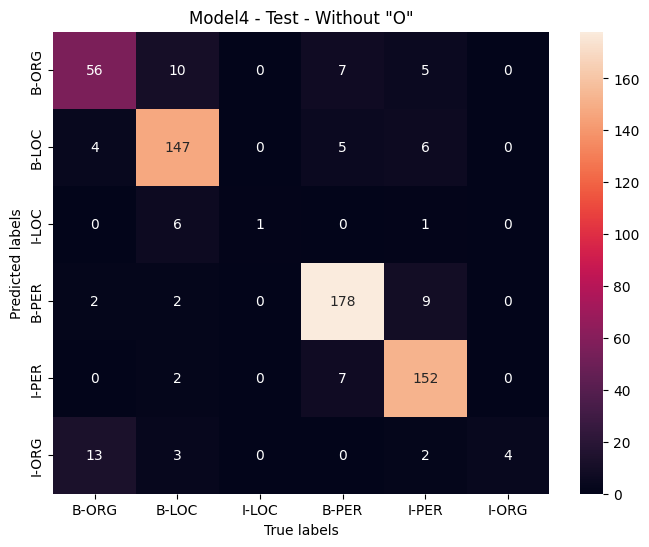

Training and evaluating Model5 on test...


100%|██████████| 5/5 [00:19<00:00,  3.95s/it]



Model5 - Test - All labels
Metric       Score
---------  -------
Precision   0.8766
Recall      0.8741
F1          0.8648


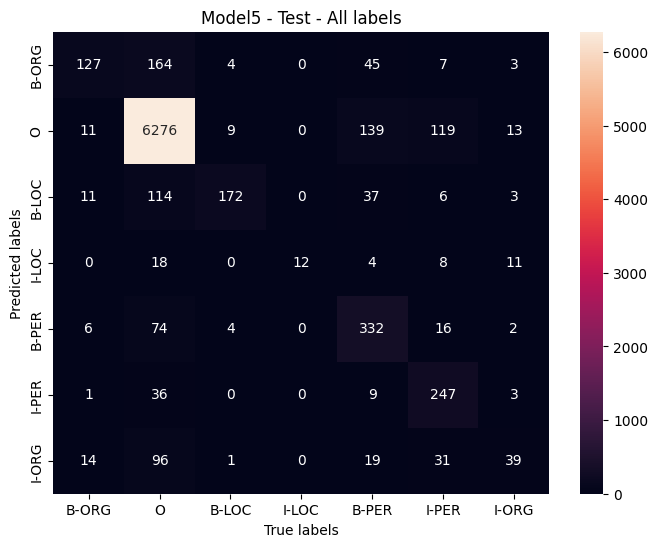


Model5 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.8004
Recall      0.5543
F1          0.6241


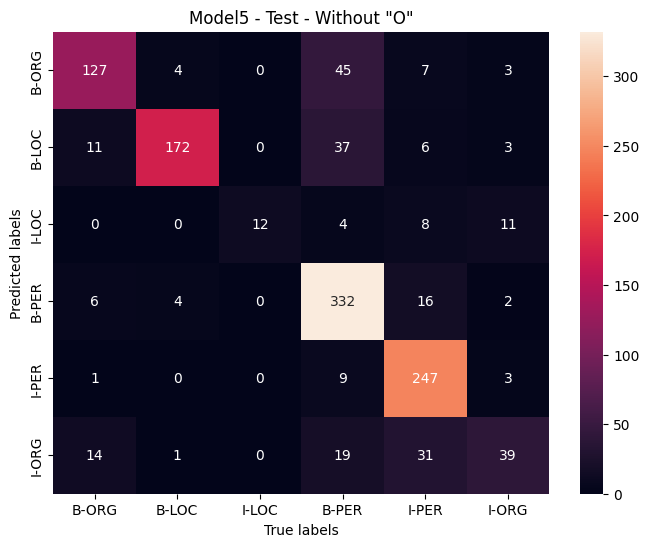

Training and evaluating Model6 on test...


100%|██████████| 5/5 [00:31<00:00,  6.28s/it]



Model6 - Test - All labels
Metric       Score
---------  -------
Precision   0.8890
Recall      0.8951
F1          0.8833


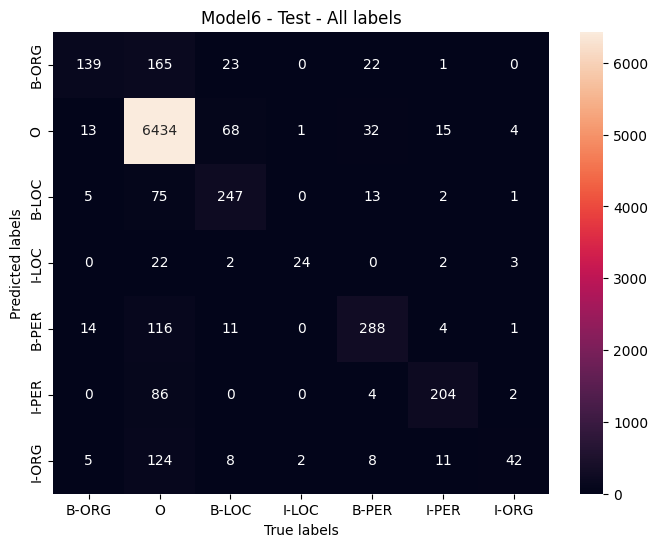


Model6 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.8667
Recall      0.5632
F1          0.6646


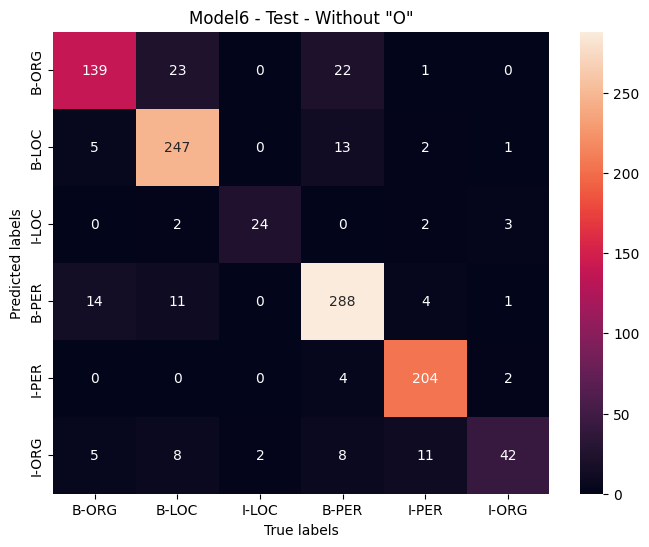

Training and evaluating Model7 on test...


100%|██████████| 5/5 [00:20<00:00,  4.12s/it]



Model7 - Test - All labels
Metric       Score
---------  -------
Precision   0.8510
Recall      0.8641
F1          0.8396


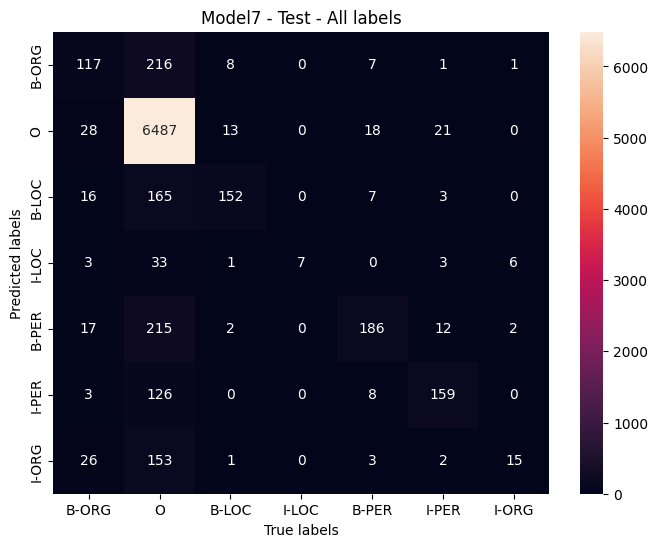


Model7 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.8144
Recall      0.3795
F1          0.5053


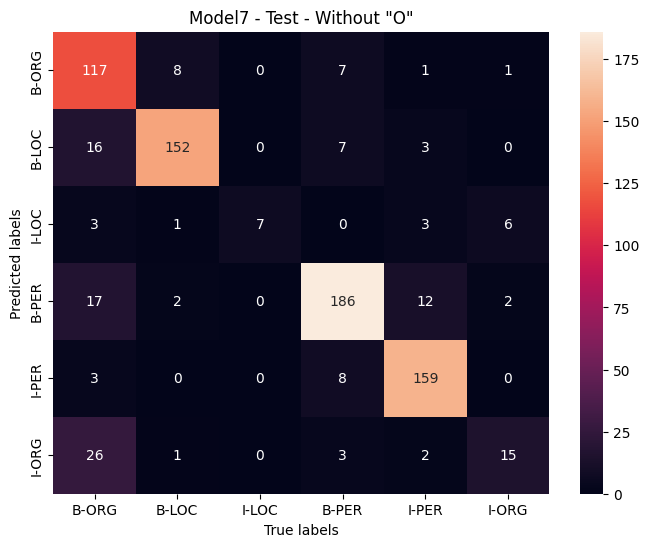

Training and evaluating Model8 on test...


100%|██████████| 5/5 [00:52<00:00, 10.50s/it]



Model8 - Test - All labels
Metric       Score
---------  -------
Precision   0.8862
Recall      0.8843
F1          0.8837


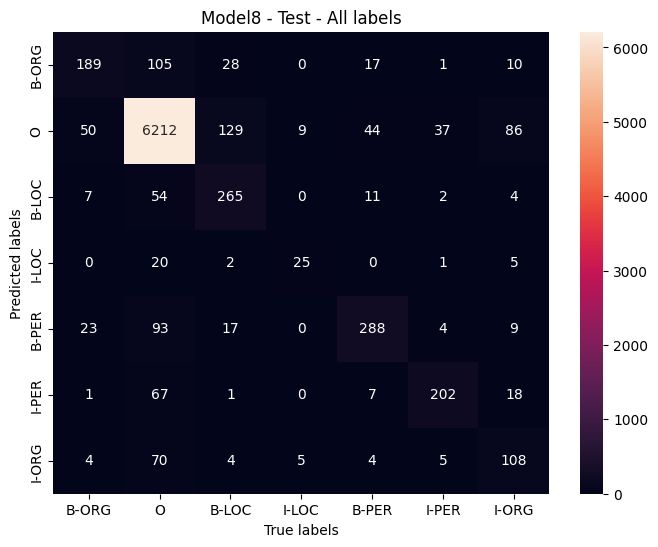


Model8 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.8513
Recall      0.6426
F1          0.7294


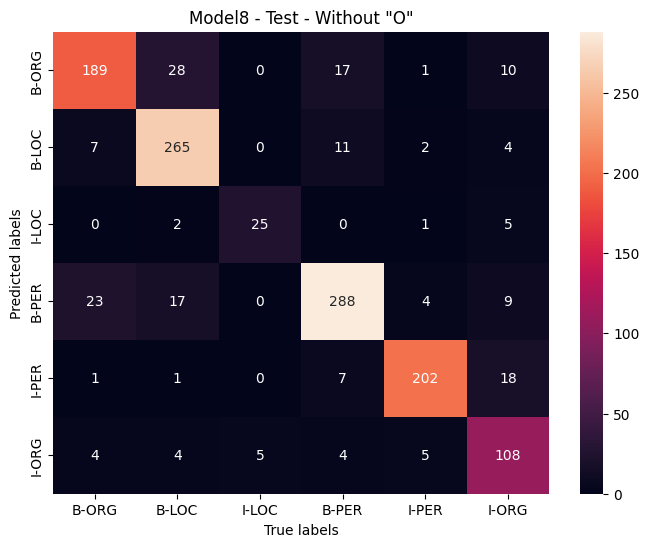

Training and evaluating Model9 on test...


100%|██████████| 5/5 [01:23<00:00, 16.62s/it]



Model9 - Test - All labels
Metric       Score
---------  -------
Precision   0.8926
Recall      0.8742
F1          0.8816


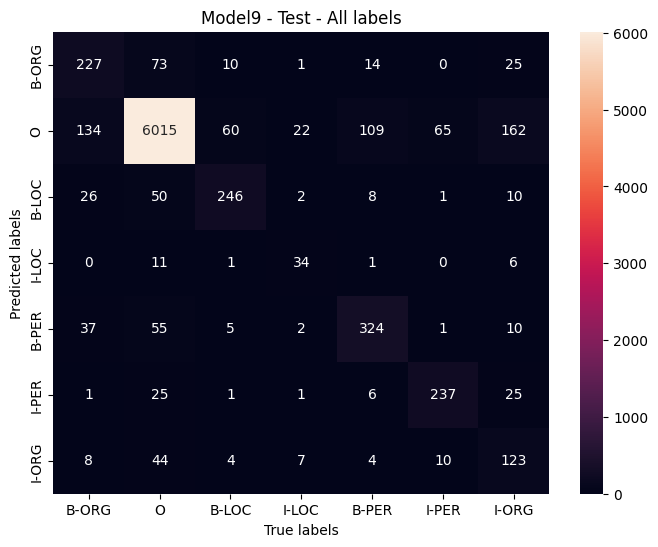


Model9 - Test - Without "O"
Metric       Score
---------  -------
Precision   0.8468
Recall      0.7106
F1          0.7720


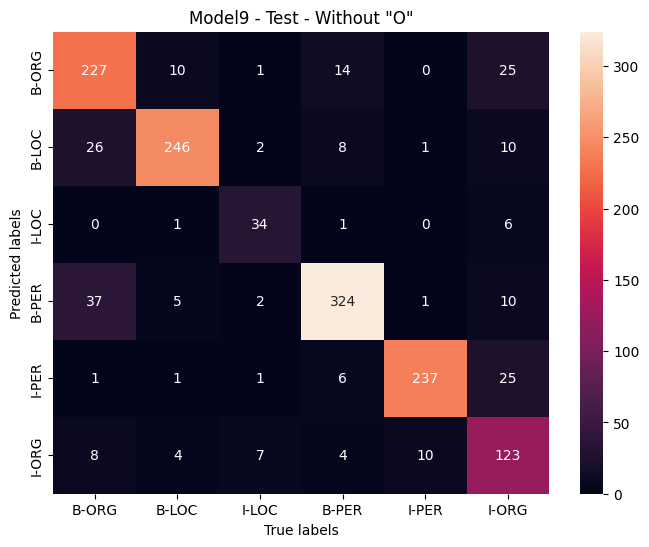

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | Model1    |           500 |          1 |            1 |   0.8236 |      0.7928 | 0.7703 |        0.1683 |           0.7537 |    0.2507 |
|  1 | Model2    |           500 |          2 |            1 |   0.8283 |      0.7905 | 0.7798 |        0.1975 |           0.6684 |    0.2850 |
|  2 | Model3    |           500 |          3 |            1 |   0.8304 |      0.7890 | 0.7940 |        0.2876 |           0.5911 |    0.3531 |
|  3 | Model4    |           500 |          1 |            2 |   0.8548 |      0.8513 | 0.8204 |        0.3210 |           0.8712 |    0

In [ ]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results.csv"
# TO DO ----------------------------------------------------------------------
results_rows = []

for model_name, params in models.items():
  print(f"Training and evaluating {model_name} on test...")

  model = NERNet(
      input_size=len(vocab),
      embedding_size=params["embedding_size"],
      hidden_size=params["hidden_size"],
      output_size=vocab.n_tags,
      n_layers=params["n_layers"],
      directions=params["directions"]
  )

  train_loop(
      model=model,
      n_epochs=N_EPOCHS,
      dataloader_train=dl_train,
      dataloader_dev=dl_dev
  )

  eval_results = evaluate(
      model=model,
      title=f"{model_name} - Test",
      dataloader=dl_test,
      vocab=vocab
  )

  results_rows.append({
      "N_MODEL": model_name,
      "HIDDEN_SIZE": params["hidden_size"],
      "N_LAYERS": params["n_layers"],
      "DIRECTIONS": params["directions"],
      "RECALL": eval_results["all_labels"]["recall"],
      "PRECISION": eval_results["all_labels"]["precision"],
      "F1": eval_results["all_labels"]["f1"],
      "RECALL_WO_O": eval_results["without_o"]["recall"],
      "PRECISION_WO_O": eval_results["without_o"]["precision"],
      "F1_WO_O": eval_results["without_o"]["f1"],
  })

results = pd.DataFrame(results_rows, columns=columns)
results.to_csv(file_name, index=False)
# TO DO ----------------------------------------------------------------------
print(tabulate(results, headers='keys', tablefmt='psql',floatfmt=".4f"))


## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Best model: Model8
Best config: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 2, 'directions': 2}


100%|██████████| 10/10 [01:45<00:00, 10.52s/it]



Best Model (Model8) - Test - All labels
Metric       Score
---------  -------
Precision   0.9003
Recall      0.9056
F1          0.8983


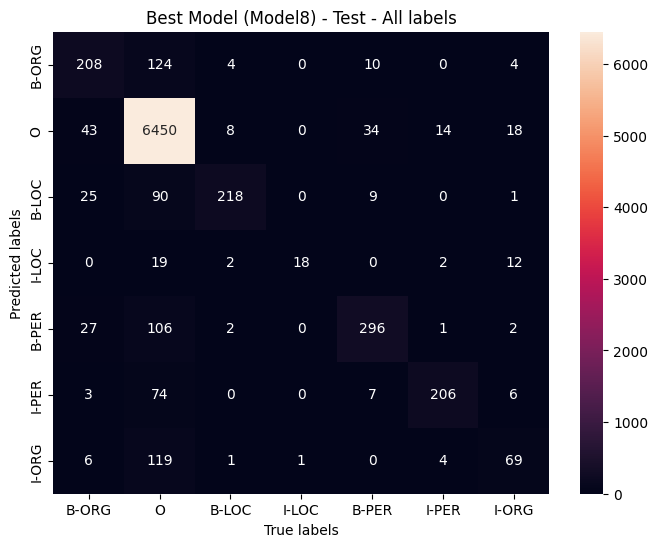


Best Model (Model8) - Test - Without "O"
Metric       Score
---------  -------
Precision   0.8844
Recall      0.6056
F1          0.7144


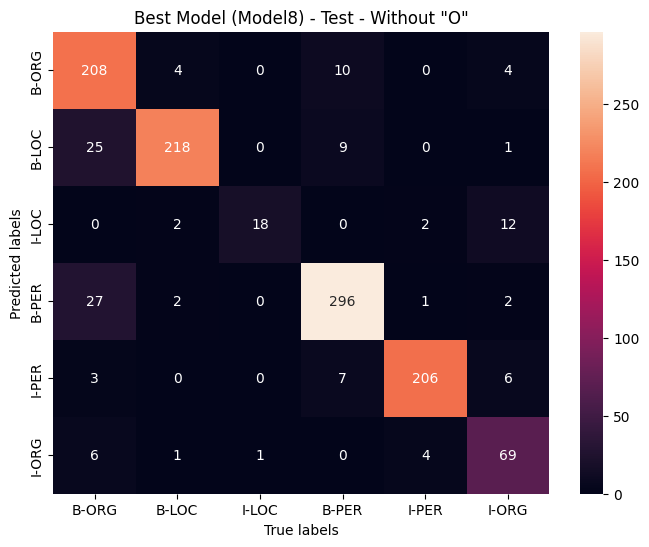

In [ ]:
best_model_cfg = {'embedding_size':EMB_DIM, 'hidden_size': -1, 'n_layers': -1, 'directions': -1}
# TO DO ----------------------------------------------------------------------
best_idx = results_dev["F1_WO_O"].idxmax()
best_model_name = results_dev.loc[best_idx, "N_MODEL"]
best_model_cfg = models[best_model_name]

print("Best model:", best_model_name)
print("Best config:", best_model_cfg)

best_model = NERNet(
    input_size=len(vocab),
    embedding_size=best_model_cfg["embedding_size"],
    hidden_size=best_model_cfg["hidden_size"],
    output_size=vocab.n_tags,
    n_layers=best_model_cfg["n_layers"],
    directions=best_model_cfg["directions"]
)

best_metrics = train_loop(
    model=best_model,
    n_epochs=10,
    dataloader_train=dl_train,
    dataloader_dev=dl_dev
)

best_test_results = evaluate(
    model=best_model,
    title=f"Best Model ({best_model_name}) - Test",
    dataloader=dl_test,
    vocab=vocab
)
# TO DO ----------------------------------------------------------------------

<br><br><br><br><br>

# Part 4 - Pretrained Embeddings



To prepare for this task, please read [this discussion](https://discuss.pytorch.org/t/can-we-use-pre-trained-word-embeddings-for-weight-initialization-in-nn-embedding/1222).

**TIP**: Ensure that the vectors are aligned with the IDs in your vocabulary. In other words, make sure that the word with ID 0 corresponds to the first vector in the GloVe matrix used to initialize `nn.Embedding`.



## Step 1: Get Data



Download the GloVe embeddings from [this link](https://nlp.stanford.edu/projects/glove/). Use the 300-dimensional vectors from `glove.6B.zip`.



In [ ]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip glove.6B.300d.txt
print("GloVe embeddings ready.")

## Step 2: Inject Embeddings

Then intialize the `nn.Embedding` module in your `NERNet` with these embeddings, so that you can start your training with pre-trained vectors.

In [ ]:
def get_emb_matrix(filepath: str, vocab: Vocab) -> np.ndarray:
  emb_matrix = np.zeros((len(vocab.word2id), 300))
  with open(filepath, "r", encoding="utf-8") as f:
    for line in f:
      parts = line.rstrip().split(" ")
      word = parts[0]
      if word in vocab.word2id:
        idx = vocab.word2id[word]
        emb_matrix[idx] = np.array(parts[1:], dtype=np.float32)
  return emb_matrix

In [ ]:
def initialize_from_pretrained_emb(model: NERNet, emb_matrix: np.ndarray):
  """
  Inject the pretrained embeddings into the model.
  :param model: model instance
  :param emb_matrix: pretrained embeddings
  """
  with th.no_grad():
    model.embedding.weight.copy_(th.tensor(emb_matrix, dtype=th.float32))

In [ ]:
# Read embeddings and inject them to a model
emb_file = 'glove.6B.300d.txt'
emb_matrix = get_emb_matrix(emb_file, vocab)
ner_glove = NERNet(input_size=vocab.n_words, embedding_size=EMB_DIM, hidden_size=500, output_size=vocab.n_tags, n_layers=1, directions=1)
initialize_from_pretrained_emb(ner_glove, emb_matrix)

## Step 3: Evaluate on Test Set

Same as the evaluation process before, please display:

1. Print a `RECALL-PRECISION-F1` scores in a tabulate format.
2. Display a `confusion matrix` plot: where the predicted labels are the rows, and the true labels are the columns.

Make sure to use the title for the plot, axis names, and the names of the tags on the X-axis.

The CSV will be submitted automatically along with your results.

In [ ]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results_glove.csv"

emb_file = "glove.6B.300d.txt"
emb_matrix = get_emb_matrix(emb_file, vocab)

results_rows = []
results_glove_dev_rows = []

for model_name, params in models.items():
  print(f"Training and evaluating {model_name} with GloVe...")

  glove_model = NERNet(
      input_size=len(vocab),
      embedding_size=params["embedding_size"],
      hidden_size=params["hidden_size"],
      output_size=vocab.n_tags,
      n_layers=params["n_layers"],
      directions=params["directions"]
  )
  initialize_from_pretrained_emb(glove_model, emb_matrix)

  train_loop(
      model=glove_model,
      n_epochs=N_EPOCHS,
      dataloader_train=dl_train,
      dataloader_dev=dl_dev
  )

  dev_eval = evaluate(
      model=glove_model,
      title=f"{model_name} GloVe - Dev",
      dataloader=dl_dev,
      vocab=vocab
  )
  results_glove_dev_rows.append({
      "N_MODEL": model_name,
      "HIDDEN_SIZE": params["hidden_size"],
      "N_LAYERS": params["n_layers"],
      "DIRECTIONS": params["directions"],
      "RECALL": dev_eval["all_labels"]["recall"],
      "PRECISION": dev_eval["all_labels"]["precision"],
      "F1": dev_eval["all_labels"]["f1"],
      "RECALL_WO_O": dev_eval["without_o"]["recall"],
      "PRECISION_WO_O": dev_eval["without_o"]["precision"],
      "F1_WO_O": dev_eval["without_o"]["f1"],
  })

  test_eval = evaluate(
      model=glove_model,
      title=f"{model_name} GloVe - Test",
      dataloader=dl_test,
      vocab=vocab
  )
  results_rows.append({
      "N_MODEL": model_name,
      "HIDDEN_SIZE": params["hidden_size"],
      "N_LAYERS": params["n_layers"],
      "DIRECTIONS": params["directions"],
      "RECALL": test_eval["all_labels"]["recall"],
      "PRECISION": test_eval["all_labels"]["precision"],
      "F1": test_eval["all_labels"]["f1"],
      "RECALL_WO_O": test_eval["without_o"]["recall"],
      "PRECISION_WO_O": test_eval["without_o"]["precision"],
      "F1_WO_O": test_eval["without_o"]["f1"],
  })

results_glove_dev = pd.DataFrame(results_glove_dev_rows, columns=columns)
results = pd.DataFrame(results_rows, columns=columns)
results.to_csv(file_name, index=False)
print(tabulate(results, headers="keys", tablefmt="psql", floatfmt=".4f"))

## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

In [ ]:
best_model_glove_cfg = {"embedding_size":EMB_DIM, "hidden_size": -1, "n_layers": -1, "directions": -1}

best_glove_idx = results_glove_dev["F1_WO_O"].idxmax()
best_glove_model_name = results_glove_dev.loc[best_glove_idx, "N_MODEL"]
best_model_glove_cfg = models[best_glove_model_name]

print("Best GloVe model:", best_glove_model_name)
print("Best config:", best_model_glove_cfg)

best_glove_model = NERNet(
    input_size=len(vocab),
    embedding_size=best_model_glove_cfg["embedding_size"],
    hidden_size=best_model_glove_cfg["hidden_size"],
    output_size=vocab.n_tags,
    n_layers=best_model_glove_cfg["n_layers"],
    directions=best_model_glove_cfg["directions"]
)
initialize_from_pretrained_emb(best_glove_model, emb_matrix)

best_glove_metrics = train_loop(
    model=best_glove_model,
    n_epochs=10,
    dataloader_train=dl_train,
    dataloader_dev=dl_dev
)

best_glove_test_results = evaluate(
    model=best_glove_model,
    title=f"Best GloVe Model ({best_glove_model_name}) - Test",
    dataloader=dl_test,
    vocab=vocab
)

# Part 5 - Error Analysis

In this part, you'll analyze the errors made by your best model to understand its strengths and weaknesses.

## Step 1: Extract Predictions

First, let's extract predictions from your best model on the test set:

In [ ]:
def get_predictions(model, dataloader, vocab, PAD_TOKEN, DEVICE):
    """
    Get predictions from the model on a dataloader.

    Returns:
        - true_tags_list: List of lists of true tag strings
        - pred_tags_list: List of lists of predicted tag strings
        - words_list: List of lists of words
    """
    import torch

    model.eval()
    true_tags_list = []
    pred_tags_list = []
    words_list = []

    with torch.no_grad():
        for batch in dataloader:
            # Dataloader yields (input_ids, labels) pairs.
            input_ids, labels = batch
            input_ids = input_ids.to(DEVICE)
            labels = labels.to(DEVICE)

            # Get model predictions.
            outputs = model(input_ids)
            _, predicted = torch.max(outputs, 2)

            # Process each sequence in the batch.
            for i in range(input_ids.size(0)):
                # Get sequence length (ignoring padding).
                seq_len = (input_ids[i] != PAD_TOKEN).sum().item()

                # Convert ids back to tag strings and words.
                true_tags = [vocab.id2tag[tag.item()] for tag in labels[i][:seq_len]]
                pred_tags = [vocab.id2tag[tag.item()] for tag in predicted[i][:seq_len]]
                words = [vocab.id2word[word.item()] for word in input_ids[i][:seq_len]]

                true_tags_list.append(true_tags)
                pred_tags_list.append(pred_tags)
                words_list.append(words)

    return true_tags_list, pred_tags_list, words_list

## Step 2: Helper Functions

Before writing the error analysis, implement two utility functions that you will need.

### 2a: `get_entities_simple(tags)`

**Goal:** Extract named entities from a single IOB tag sequence.

**Input:** A list of IOB tag strings, e.g. `['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']`

**Output:** A list of tuples `(start_idx, end_idx, entity_type)` where:
- `start_idx` is the index of the `B-` tag
- `end_idx` is the index of the last `I-` tag of that entity (or same as `start_idx` if the entity is a single token)
- `entity_type` is the string after `B-`/`I-` (e.g. `"PER"`, `"LOC"`, `"ORG"`)

**Logic:** Walk through the tag list. When you see a `B-X` tag, start a new entity. Keep extending it while the next tags are `I-X` (same type). When the entity ends, append the tuple. Ignore `O` tags.

**Example:**
```python
tags = ['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']
get_entities_simple(tags)
# Returns: [(1, 2, 'PER'), (4, 4, 'LOC')]
```

### 2b: `has_overlap(start1, end1, start2, end2)`

**Goal:** Check if two index spans share at least one position.

**Input:** Four integers — start and end indices of two spans.

**Output:** `True` if they overlap, `False` otherwise.

**Example:**
```python
has_overlap(1, 3, 2, 5)  # True  (overlap at indices 2, 3)
has_overlap(1, 2, 4, 5)  # False (no shared indices)
```

In [ ]:
def get_entities_simple(tags):
    """
    Extract entities from a sequence of IOB tags.

    Args:
        tags: List of tag strings, e.g. ['O', 'B-PER', 'I-PER', 'O']

    Returns:
        List of (start_idx, end_idx, entity_type) tuples.
        Example: [(1, 2, 'PER')]
    """
    entities = []
    # TODO: Implement entity extraction
    return entities

def has_overlap(start1, end1, start2, end2):
    """
    Check if two spans overlap (share at least one index).

    Args:
        start1, end1: start and end indices of the first span
        start2, end2: start and end indices of the second span

    Returns:
        True if the spans overlap, False otherwise.
    """
    # TODO: Implement overlap checking
    return False

## Step 3: Implement Entity-Level Error Analysis

**Goal:** Compare the true and predicted entity spans (extracted using `get_entities_simple`) to count and categorize errors at the **entity level**.

**Function signature:**
```python
def simple_analyze_errors(true_tags, pred_tags, words) -> dict
```

**Inputs:**
- `true_tags`: list of lists of tag strings (one inner list per sentence)
- `pred_tags`: list of lists of tag strings (one inner list per sentence)
- `words`: list of lists of word strings (one inner list per sentence)

**What to do — for each sentence:**
1. Extract true entities using `get_entities_simple(true_tags[i])`
2. Extract predicted entities using `get_entities_simple(pred_tags[i])`
3. Classify each **true entity** into one of these categories:
   - **Correct:** A predicted entity has the exact same `(start, end, type)`.
   - **Type error:** A predicted entity has the same `(start, end)` but a **different** type (e.g., true=`PER`, predicted=`ORG`).
   - **Boundary error:** A predicted entity **overlaps** (use `has_overlap`) and has the **same type**, but the start/end indices differ.
   - **Missed:** No predicted entity overlaps with this true entity at all.
4. Also count **Spurious** predictions: predicted entities that do **not** overlap with any true entity.

**Return value — a dictionary:**
```python
{
    'total_entities': int,       # total number of true entities across all sentences
    'correct_entities': int,     # number of exact matches
    'accuracy': float,           # correct_entities / total_entities
    'error_counts': {
        'type_error': int,
        'boundary_error': int,
        'missed': int,
        'spurious': int
    },
    'error_examples': {          # store up to 3 examples per category
        'type_error': [(words, true_entity, pred_entity), ...],
        'boundary_error': [(words, true_entity, pred_entity), ...],
        'missed': [(words, true_entity), ...],
        'spurious': [(words, pred_entity), ...]
    }
}
```

**Example walkthrough:**
```python
true_tags = [['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'I-LOC', 'O']]
pred_tags = [['O', 'B-PER', 'O',     'O', 'B-ORG', 'I-ORG', 'O']]
words     = [['The', 'John', 'Smith', 'visited', 'New', 'York', 'yesterday']]

# True entities:  [(1,2,'PER'), (4,5,'LOC')]
# Pred entities:  [(1,1,'PER'), (4,5,'ORG')]
#
# (1,2,'PER') vs (1,1,'PER') → boundary_error (same type PER, overlapping spans, but end differs)
# (4,5,'LOC') vs (4,5,'ORG') → type_error (same span, different type)
```

In [ ]:
def simple_analyze_errors(true_tags, pred_tags, words):
    """
    Analyze errors in NER predictions at the entity level.

    Args:
        true_tags: List of lists of true tag strings (one list per sentence)
        pred_tags: List of lists of predicted tag strings (one list per sentence)
        words: List of lists of word strings (one list per sentence)

    Returns:
        dict with keys: total_entities, correct_entities, accuracy,
                        error_counts (dict), error_examples (dict)
    """
    # TODO: Implement error analysis
    # 1. Initialize counters and example lists for each error category
    # 2. For each sentence, extract true and predicted entities using get_entities_simple
    # 3. For each true entity, check predicted entities to classify as:
    #    correct, type_error, boundary_error, or missed
    # 4. For each predicted entity, check if it is spurious (no overlap with any true entity)
    # 5. Store up to 3 examples per error category
    # 6. Return the results dictionary

    return {
        'total_entities': 0,
        'correct_entities': 0,
        'accuracy': 0.0,
        'error_counts': {
            'type_error': 0,
            'boundary_error': 0,
            'missed': 0,
            'spurious': 0
        },
        'error_examples': {
            'type_error': [],
            'boundary_error': [],
            'missed': [],
            'spurious': []
        }
    }

## Step 4: Display the Error Analysis

**Goal:** Print a readable summary of the error analysis dictionary returned by `simple_analyze_errors`.

**Function signature:**
```python
def print_error_analysis(analysis):
```

**Input:** The dictionary returned by `simple_analyze_errors`.

**What to print — three sections:**

**Section 1 — Overall statistics** (use `tabulate` or simple print statements):
```
Total entities:     500
Correct:            420 (84.0%)
Type errors:         15
Boundary errors:     25
Missed:              40
Spurious:            30
```

**Section 2 — Examples for each error type.** Print up to 3 examples per category, showing the sentence words and the relevant entity span. Format each example like:
```
[Type Error] "... New York ..." — true: LOC(4,5), predicted: ORG(4,5)
[Missed]     "... John Smith ..." — true: PER(1,2), predicted: (none)
```

**Section 3 — Which entity type (PER / LOC / ORG) has the most errors?** Print one line stating the answer.

In [ ]:
def print_error_analysis(analysis):
    """
    Print a readable summary of the error analysis results.

    Args:
        analysis: Dictionary returned by simple_analyze_errors, containing:
                  total_entities, correct_entities, accuracy,
                  error_counts (dict), error_examples (dict)
    """
    # TODO: Implement printing function
    # Section 1: Print overall statistics (total, correct, each error count)
    # Section 2: Print up to 3 examples per error category
    # Section 3: Print which entity type (PER/LOC/ORG) has the most errors
    pass

## Step 5: Improvement Suggestions

**Goal:** Based on the output of your error analysis, write **3 concrete improvement suggestions** below (no code required — just text).

**Requirements:**
- Write 2–4 sentences per suggestion.
- Each suggestion **must reference a specific finding** from your error analysis (e.g., "42% of errors are boundary errors on PER entities, which suggests...").
- Choose 3 of the following directions:
  1. Using a **CRF layer** on top of the LSTM to enforce valid IOB transitions
  2. Using **subword or character-level embeddings** to handle rare / OOV entity words
  3. Adding more **training data or data augmentation** for the weakest entity type
  4. Using **contextual embeddings** (e.g., BERT) instead of static word embeddings
  5. **Post-processing rules** to fix common boundary errors

**Expected output:** A markdown cell (below) with three numbered paragraphs.

In [ ]:
# First, extract predictions from your best model on the test set
true_tags_list, pred_tags_list, words_list = get_predictions(model, dl_test, vocab, PAD_TOKEN, DEVICE)

# Run the error analysis
analysis = simple_analyze_errors(true_tags_list, pred_tags_list, words_list)

# Display the results
print_error_analysis(analysis)

### Your Improvement Suggestions

*(Write your 3 suggestions here)*

1. ...

2. ...

3. ...

# Testing

Before running the tests:
1. Create a **sharing link** to your notebook with **editor access**.
2. Paste it in the `NOTEBOOK_LINK` variable below.

Then run the test cells to create the `results.json` file.

In [ ]:
NOTEBOOK_LINK = None

In [ ]:
########################################
# Tests

import json

def test_link():
    return {
        'link': NOTEBOOK_LINK
    }

train_ds = read_data("data/train.txt")
dev_ds = read_data("data/dev.txt")
test_ds = read_data("data/test.txt")
def test_read_data():
    result = {
        'lengths': (len(train_ds), len(dev_ds), len(test_ds)),
    }
    return result

vocab = Vocab(train_ds)
def test_vocab():
    sent = vocab.index_words(["I", "am", "Spongebob"])
    return {
        'length': vocab.n_words,
        'tag2id_length': len(vocab.tag2id),
        "Spongebob": sent[2]
    }

train_sequences = prepare_data(train_ds, vocab)
dev_sequences = prepare_data(dev_ds, vocab)
test_sequences = prepare_data(test_ds, vocab)

def test_count_oov():
    return {
        'dev_oov': count_oov(dev_sequences),
        'test_oov': count_oov(test_sequences)
    }

BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

def test_prepare_data_loader():
    return {
        'lengths': (len(dl_train), len(dl_dev), len(dl_test))
    }


def test_NERNet():
    # Extract best model configuration
    hidden_size = best_model_cfg['hidden_size']
    n_layers = best_model_cfg['n_layers']
    directions = best_model_cfg['directions']


    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

def test_glove():
    # Get embeddings
    emb_file = 'glove.6B.300d.txt'
    emb_matrix = get_emb_matrix(emb_file, vocab)

    # Extract best model configuration
    hidden_size = best_model_glove_cfg['hidden_size']
    n_layers = best_model_glove_cfg['n_layers']
    directions = best_model_glove_cfg['directions']

    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)
    initialize_from_pretrained_emb(best_model, emb_matrix)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

TESTS = [
    test_link,
    test_read_data,
    test_vocab,
    test_count_oov,
    test_prepare_data_loader,
    test_NERNet,
    test_glove
]

# Run tests and save results
res = {}
for test in TESTS:
    try:
        cur_res = test()
        res.update({test.__name__: cur_res})
    except Exception as e:
        import traceback
        res.update({test.__name__: repr(e) + "\n" + traceback.format_exc()})

with open('results.json', 'w') as f:
    json.dump(res, f, indent=2)

########################################

---

# 📤 Submit Your Assignment to GitHub

## Step 1: Authentication Setup (One-Time)

Before you can submit, you need to set up GitHub authentication.

### Creating a GitHub Personal Access Token:

1. **Go to GitHub Token Settings**: [https://github.com/settings/tokens](https://github.com/settings/tokens)

2. **Click "Generate new token (classic)"**

3. **Configure your token**:
   - **Note**: "NLP Course Assignments" (or any name you like)
   - **Expiration**: 90 days (or custom)
   - **Select scopes**: Check **`repo`** (full control of private repositories)

4. **Click "Generate token"**

5. **IMPORTANT**: Copy the token immediately and save it somewhere safe!
   - Like Colab Secrets (see picture)
   - You won't be able to see it again
   - You can reuse this token for all assignments
   - Don't share it with anyone

### Run the authentication cell below

You only need to do this **once per Colab session**. If you restart the runtime, you'll need to re-run the authentication cell.

---

In [ ]:
"""
GitHub Authentication Setup
Run this cell ONCE to set up your GitHub credentials
"""

import os
from getpass import getpass

def setup_github_auth():
    """Set up GitHub credentials - run once per Colab session"""
    global GITHUB_USERNAME, GITHUB_TOKEN

    print("🔐 GitHub Authentication Setup")
    print("=" * 60)

    GITHUB_USERNAME = input("GitHub username: ")
    GITHUB_TOKEN = getpass("GitHub Personal Access Token (hidden): ")

    print("\n✅ Credentials saved for this session!")
    print("You can now run the submission cell below.")
    print("\n💡 Tip: Your credentials are only stored in this runtime.")
    print("If you restart the runtime, you'll need to run this cell again.")

# Run the setup
setup_github_auth()

---

## Step 2: Submit Your Results

Once you've:
- ✅ Completed all the code cells above
- ✅ Run all the test cells
- ✅ Generated `results.json`
- ✅ Run the authentication cell

You can now submit your assignment by running the cell below!

### What you'll need:
- Your **GitHub Classroom repository URL**
  - You received this when you accepted the assignment
  - Format: `https://github.com/NLP-Reichman/2026-assignment-2-team-name`
- (Optional) A custom commit message

### After submission:
- Check your repository to see `results.json` has been uploaded
- Visit the **Actions** tab to see your autograding results
- Results typically appear within 1-2 minutes

---

In [ ]:
"""
Submit Assignment to GitHub
Run this cell to push your results.json to GitHub
"""

import os
import subprocess
import json

def check_credentials():
    """Check if credentials are set"""
    try:
        _ = GITHUB_USERNAME
        _ = GITHUB_TOKEN
        return True
    except NameError:
        print("\u274c GitHub credentials not found!")
        print("Please run the authentication cell above first.")
        return False


def check_results_file():
    """Check if results.json exists"""
    if not os.path.exists('results.json'):
        print("\u274c results.json not found!")
        print("\nPlease run all the test cells above to generate results.json")
        return False

    # Display test summary
    try:
        with open('results.json', 'r') as f:
            results = json.load(f)

        print("\U0001f4ca Test Results Found:")
        print("-" * 60)
        for test_name in results.keys():
            print(f"  \u2713 {test_name}")
        print("-" * 60)
        return True
    except Exception as e:
        print(f"\u26a0\ufe0f  Warning: Could not read results.json: {e}")
        return True  # Still allow submission


def submit_to_github(repo_url, commit_message=None):
    """Submit results.json to GitHub repository"""

    if commit_message is None:
        commit_message = "Submit assignment results from Colab"

    print("\n\U0001f680 Submitting to GitHub...")
    print("=" * 60)

    # Create temporary directory
    temp_dir = '/content/github_submission'
    if os.path.exists(temp_dir):
        subprocess.run(['rm', '-rf', temp_dir], check=True, capture_output=True)

    os.makedirs(temp_dir, exist_ok=True)
    os.chdir(temp_dir)

    try:
        # Configure git
        subprocess.run(['git', 'config', '--global', 'user.email',
                       f'{GITHUB_USERNAME}@users.noreply.github.com'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'config', '--global', 'user.name',
                       GITHUB_USERNAME],
                      check=True, capture_output=True)

        # Clone repository with authentication
        auth_url = repo_url.replace('https://', f'https://{GITHUB_USERNAME}:{GITHUB_TOKEN}@')

        print("\U0001f4e5 Cloning repository...")
        result = subprocess.run(['git', 'clone', auth_url, 'repo'],
                              capture_output=True, text=True)

        if result.returncode != 0:
            print(f"\u274c Error cloning repository:")
            print(result.stderr)
            print("\n\U0001f4a1 Troubleshooting:")
            print("  - Check that your repository URL is correct")
            print("  - Verify your token has 'repo' scope")
            print("  - Make sure you've accepted the assignment")
            return False

        # Change to repo directory
        os.chdir('repo')

        # Copy results.json
        print("\U0001f4dd Copying results.json...")
        subprocess.run(['cp', '/content/results.json', 'results.json'],
                      check=True, capture_output=True)

        # Copy CSV result files if they exist
        for csv_file in ['NER_results.csv', 'NER_results_glove.csv']:
            csv_path = f'/content/{csv_file}'
            if os.path.exists(csv_path):
                print(f"\U0001f4dd Copying {csv_file}...")
                subprocess.run(['cp', csv_path, csv_file],
                              check=True, capture_output=True)

        # Check for changes
        status = subprocess.run(['git', 'status', '--porcelain'],
                              capture_output=True, text=True)

        if not status.stdout.strip():
            print("\n\u2139\ufe0f  No changes detected - results.json is unchanged")
            print("\u2705 Your repository is already up to date!")
            return True

        # Commit and push
        print(f"\U0001f4ac Commit message: '{commit_message}'")
        print("\U0001f4e4 Pushing to GitHub...")

        subprocess.run(['git', 'add', 'results.json',
                        'NER_results.csv', 'NER_results_glove.csv'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'commit', '-m', commit_message],
                      check=True, capture_output=True)
        subprocess.run(['git', 'push'],
                      check=True, capture_output=True)

        print("\n" + "=" * 60)
        print("\u2705 SUCCESS! Assignment submitted!")
        print("=" * 60)
        print(f"\n\U0001f4ca Repository: {repo_url}")
        print(f"\U0001f4ca Autograding: {repo_url.replace('.git', '')}/actions")
        print("\n\U0001f4a1 Your grade will appear in the Actions tab in ~1 minute")

        return True

    except subprocess.CalledProcessError as e:
        print(f"\n\u274c Git error occurred")
        if hasattr(e, 'stderr') and e.stderr:
            print(f"Details: {e.stderr}")
        return False
    except Exception as e:
        print(f"\n\u274c Unexpected error: {e}")
        return False
    finally:
        # Return to /content
        os.chdir('/content')


def main():
    """Main submission workflow"""
    print("=" * 60)
    print("\U0001f4e4 Assignment Submission")
    print("=" * 60)

    # Check credentials
    if not check_credentials():
        return

    # Check results file
    if not check_results_file():
        return

    # Get repository URL
    print("\n\U0001f4cd Enter your GitHub Classroom repository URL")
    print("Example: https://github.com/NLP-Reichman/2026-assignment-2-username")
    repo_url = input("\nRepository URL: ").strip()

    # Validate URL
    if not repo_url.startswith('https://github.com/'):
        print("\u274c Invalid URL - must start with https://github.com/")
        return

    # Get commit message (optional)
    print("\n\U0001f4ac Commit Message (optional)")
    print("Press Enter for default message, or type your own:")
    commit_msg = input("Message: ").strip()

    if not commit_msg:
        commit_msg = "Submit assignment results from Colab"

    # Confirm submission
    print("\n" + "=" * 60)
    print("Ready to submit:")
    print(f"  Repository: {repo_url}")
    print(f"  File: results.json")
    print(f"  Message: {commit_msg}")
    print("=" * 60)

    confirm = input("\nProceed? (yes/no): ").strip().lower()

    if confirm in ['yes', 'y']:
        success = submit_to_github(repo_url, commit_msg)
        if success:
            print("\n\U0001f389 All done!")
    else:
        print("\n\u274c Submission cancelled")


# Run submission
main()